# Few-Shot Learning — Wind Turbine Blade Damage Detection
## Yang Dataset | Lightweight YOLOv8 (~2.1M params)

Implements **few-shot learning** on the Yang blade dataset (Blade_1 – Blade_15).  
The raw annotations are **LabelMe JSON polygons** → converted to YOLO bounding-box format.

### Classes (damage-focused):
| ID | Name | Source labels |
|----|------|--------------|
| 0 | `contamination` | `Surface;contamination;dirt`, `surface;contamination;other` |
| 1 | `erosion` | `leading edge;erosion;*` (all variants) |
| 2 | `structural` | `trailing edge;crack;*`, `add-on;LPS;worn or burnt` |

### Key Techniques:
1. **Balanced Few-Shot Sampling** – equal class representation
2. **Heavy Augmentation** – mosaic, mixup, copy-paste
3. **Transfer Learning** – pretrained YOLOv8n backbone
4. **Cosine Annealing LR** – stable convergence on small data
5. **Early Stopping** – prevent overfitting

### Metrics Reported:
`mAP@0.5`, `mAP@0.5:0.95`, `mAP@0.75` (≈0.9 proxy), `Precision`, `Recall`,  
Class-wise **Precision-Recall Curves**, **Confusion Matrix**


## 1. Import Required Libraries & Set Seeds

In [1]:
import os, sys, json, random, shutil
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
import cv2
import yaml
import torch
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ── Install / import ultralytics (works on Kaggle & locally) ──────────────────
try:
    from ultralytics import YOLO
    print("✓ Ultralytics YOLO ready")
except ImportError:
    print("Installing ultralytics …")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "ultralytics", "-q"])
    from ultralytics import YOLO
    print("✓ Ultralytics YOLO installed")

# ── Reproducibility ───────────────────────────────────────────────────────────
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# ── Device info ───────────────────────────────────────────────────────────────
print(f"Working dir : {os.getcwd()}")
print(f"PyTorch     : {torch.__version__}")
print(f"CUDA        : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU         : {torch.cuda.get_device_name(0)}")
    print(f"VRAM        : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


Installing ultralytics …
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✓ Ultralytics YOLO installed
Working dir : /kaggle/working
PyTorch     : 2.9.0+cu126
CUDA        : True
GPU         : Tesla T4
VRAM        : 15.6 GB


## 2. Configuration & Path Setup

In [3]:
import os

# ── Environment detection ─────────────────────────────────────────────────────
ON_KAGGLE = os.path.exists("/kaggle/input")

if ON_KAGGLE:
    # Confirmed mount path: Blade_* folders live directly here ↓
    YANG_RAW = Path("/kaggle/input/datasets/rishitha2007/yang-dataset/blade_1_15_with_labeldata")
    BASE_DIR = Path("/kaggle/working")
    print("▶  Running on KAGGLE")
else:
    # ── Local / PC paths ──────────────────────────────────────────────────────
    YANG_RAW = Path(r"C:\SEM-6\Analog Computing\Project\Dataset\Yang Dataset\blade_1_15_with_labeldata\blade_1_15_with_labeldata")
    BASE_DIR = Path(r"C:\SEM-6\Analog Computing\Project")
    print("▶  Running LOCALLY")

# ── Derived paths (same for both environments) ────────────────────────────────
YOLO_DATASET = BASE_DIR / "yang_yolo_dataset"
OUTPUT_DIR   = BASE_DIR / "fewshot_yang"
BASE_MODEL_PATH = BASE_DIR / "yolov8n.pt"

# ── Few-shot settings ─────────────────────────────────────────────────────────
N_SHOTS = [3, 5, 10, 15]

# ── Class mapping: LabelMe raw label → integer class ID ──────────────────────
LABEL_MAP = {
    "Surface;contamination;dirt"  : 0,
    "surface;contamination;dirt"  : 0,
    "Surface;contamination;other" : 0,
    "surface;contamination;other" : 0,
    "leading edge;erosion;coating or LEP only" : 1,
    "leading edge;erosion;continuous or deep"  : 1,
    "leading edge;erosion;spotty or laminate"  : 1,
    "leading edge;erosion;eroded tip"          : 1,
    "trailing edge;crack;superficial"          : 2,
    "add-on;LPS;worn or burnt"                 : 2,
}
CLASS_NAMES  = ["contamination", "erosion", "structural"]
NC           = len(CLASS_NAMES)
CLASS_COLORS = ["#FF9500", "#FF0000", "#0000FF"]

# ── Verify paths ──────────────────────────────────────────────────────────────
print("=" * 58)
print("Path Verification")
print("=" * 58)
blade_dirs = sorted(YANG_RAW.glob("Blade_*")) if YANG_RAW.exists() else []
print(f"{'✓' if YANG_RAW.exists() else '✗'}  Raw dataset  : {YANG_RAW}")
if blade_dirs:
    print(f"    ✓ Found {len(blade_dirs)} blade folders: {[d.name for d in blade_dirs]}")
else:
    print(f"    ⚠  No Blade_* folders found — check path above")
print(f"{'✓' if BASE_MODEL_PATH.exists() else '○'}  Base model   : {BASE_MODEL_PATH}")
print(f"     (○ = will be auto-downloaded by ultralytics on first use)")
print()
print(f"  YOLO dataset → {YOLO_DATASET}")
print(f"  Output dir   → {OUTPUT_DIR}")


▶  Running on KAGGLE
Path Verification
✓  Raw dataset  : /kaggle/input/datasets/rishitha2007/yang-dataset/blade_1_15_with_labeldata
    ✓ Found 15 blade folders: ['Blade_1', 'Blade_10', 'Blade_11', 'Blade_12', 'Blade_13', 'Blade_14', 'Blade_15', 'Blade_2', 'Blade_3', 'Blade_4', 'Blade_5', 'Blade_6', 'Blade_7', 'Blade_8', 'Blade_9']
○  Base model   : /kaggle/working/yolov8n.pt
     (○ = will be auto-downloaded by ultralytics on first use)

  YOLO dataset → /kaggle/working/yang_yolo_dataset
  Output dir   → /kaggle/working/fewshot_yang


## 3. Convert LabelMe JSON → YOLO Format & Build Dataset

Each blade folder contains JPG images and per-image LabelMe JSON files with polygon annotations.  
We convert **polygons → axis-aligned bounding boxes** in YOLO format (`class cx cy w h`, normalised).  
Annotated images are split 80 / 20 into **train / val**.  Unannotated images are ignored.

In [4]:
def polygon_to_bbox_yolo(points, img_w, img_h):
    """Convert a list of polygon (x,y) points to YOLO normalised bbox."""
    xs = [p[0] for p in points]
    ys = [p[1] for p in points]
    x_min, x_max = max(0.0, min(xs)), min(float(img_w), max(xs))
    y_min, y_max = max(0.0, min(ys)), min(float(img_h), max(ys))
    cx = (x_min + x_max) / 2.0 / img_w
    cy = (y_min + y_max) / 2.0 / img_h
    bw = (x_max - x_min) / img_w
    bh = (y_max - y_min) / img_h
    return cx, cy, bw, bh


def verify_image(img_path: Path) -> tuple[int, int] | None:
    """
    Verify the image file is readable and return (width, height).
    Returns None if the file is corrupt or unreadable.
    """
    try:
        with Image.open(img_path) as img:
            w, h = img.size
        if w > 0 and h > 0:
            return w, h
    except Exception:
        pass
    return None


def build_yolo_dataset(raw_root: Path, out_root: Path, label_map: dict,
                       val_ratio: float = 0.20, seed: int = 42):
    """
    Parse ALL LabelMe JSON files from raw_root (Blade_1 … Blade_15):
      - Converts polygon annotations → YOLO bbox .txt files
      - Copies the actual .jpg/.png image next to the label
      - Verifies every image is readable before including it
      - Splits annotated images 80/20 into train / val
      - Prints full diagnostics so nothing is hidden

    Images WITHOUT json files → not included (no labels to train on).
    JSON files whose shapes are ALL outside label_map → skipped (no damage labels).
    """
    random.seed(seed)
    out_root = Path(out_root)
    for split in ["train", "val"]:
        (out_root / split / "images").mkdir(parents=True, exist_ok=True)
        (out_root / split / "labels").mkdir(parents=True, exist_ok=True)

    # ── Diagnostics counters ──────────────────────────────────────────────────
    n_jsons_found        = 0
    n_img_missing        = 0   # JSON found but image file not on disk
    n_img_corrupt        = 0   # Image file exists but is unreadable
    n_no_damage_labels   = 0   # JSON has shapes, but none match label_map
    n_no_shapes          = 0   # JSON has zero shapes at all
    n_dim_missing        = 0   # JSON has 0 imageWidth/Height
    records              = []  # valid records to copy

    all_blade_dirs = sorted(raw_root.glob("Blade_*"))
    total_images_on_disk = sum(
        1 for bd in all_blade_dirs
        for _ in (list(bd.glob("*.jpg")) + list(bd.glob("*.jpeg")) + list(bd.glob("*.png")))
    )

    for blade_dir in all_blade_dirs:
        json_files = sorted(blade_dir.glob("*.json"))
        n_jsons_found += len(json_files)

        for json_file in json_files:
            with open(json_file, "r", encoding="utf-8") as f:
                ann = json.load(f)

            shapes = ann.get("shapes", [])
            if not shapes:
                n_no_shapes += 1
                continue

            # ── Get image dimensions from JSON metadata ───────────────────────
            img_h_json = ann.get("imageHeight", 0)
            img_w_json = ann.get("imageWidth",  0)

            # ── Locate the image file ─────────────────────────────────────────
            img_stem = Path(ann.get("imagePath", json_file.stem)).stem
            img_path = None
            for ext in [".jpg", ".jpeg", ".png"]:
                candidate = blade_dir / f"{img_stem}{ext}"
                if candidate.exists():
                    img_path = candidate
                    break

            if img_path is None:
                n_img_missing += 1
                continue

            # ── Verify image is readable; get real dimensions ─────────────────
            dims = verify_image(img_path)
            if dims is None:
                n_img_corrupt += 1
                continue
            img_w, img_h = dims

            # Fall back to JSON dims if PIL gives very different values
            # (shouldn't happen, but safety net)
            if img_w_json > 0 and img_h_json > 0:
                img_w, img_h = img_w_json, img_h_json

            if img_w == 0 or img_h == 0:
                n_dim_missing += 1
                continue

            # ── Convert matching shapes to YOLO format ────────────────────────
            yolo_lines    = []
            classes_found = set()

            for shape in shapes:
                raw_label = shape.get("label", "").strip()
                if raw_label not in label_map:
                    continue                             # non-damage annotation, skip shape
                cls_id = label_map[raw_label]
                points = shape.get("points", [])
                if len(points) < 2:
                    continue

                cx, cy, bw, bh = polygon_to_bbox_yolo(points, img_w, img_h)
                if bw <= 0 or bh <= 0:
                    continue
                yolo_lines.append(f"{cls_id} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}")
                classes_found.add(cls_id)

            if not yolo_lines:
                n_no_damage_labels += 1
                continue                                 # image exists but has no damage labels

            records.append({
                "img_path"       : img_path,
                "yolo_lines"     : yolo_lines,
                "classes_present": classes_found,
                "stem"           : img_path.stem,
            })

    # ── Print full diagnostics ────────────────────────────────────────────────
    print("=" * 58)
    print("Dataset Build — Diagnostics")
    print("=" * 58)
    print(f"  Total images on disk         : {total_images_on_disk}")
    print(f"  Total JSON annotation files  : {n_jsons_found}")
    print(f"  ── Skipped reasons ──────────────────────────────")
    print(f"     JSON has no shapes         : {n_no_shapes}")
    print(f"     Image file not found       : {n_img_missing}")
    print(f"     Image file corrupt         : {n_img_corrupt}")
    print(f"     Missing dimensions         : {n_dim_missing}")
    print(f"     No damage labels in JSON   : {n_no_damage_labels}  "
          f"(only add-on/markings/OK labels)")
    print(f"  ── Included ─────────────────────────────────────")
    print(f"     Usable annotated images    : {len(records)}")
    print(f"     (Images copied WITH their labels)")

    # ── Class distribution before split ──────────────────────────────────────
    class_img_counts = Counter()
    class_ann_counts = Counter()
    for rec in records:
        for cls_id in rec["classes_present"]:
            class_img_counts[cls_id] += 1
        for line in rec["yolo_lines"]:
            cls_id = int(line.split()[0])
            class_ann_counts[cls_id] += 1

    print(f"\n  Class distribution (all usable images):")
    for cls_id in range(NC):
        print(f"     {CLASS_NAMES[cls_id]:15s}: {class_ann_counts[cls_id]:3d} annotations "
              f"| {class_img_counts[cls_id]:3d} images")

    if len(records) == 0:
        print("\n⚠  No usable records found! Check that YANG_RAW path is correct")
        print(f"   YANG_RAW = {raw_root}")
        return [], []

    # ── Train / Val split ─────────────────────────────────────────────────────
    random.shuffle(records)
    n_val    = max(1, int(len(records) * val_ratio))
    val_recs = records[:n_val]
    trn_recs = records[n_val:]

    # ── Copy images + write label files ──────────────────────────────────────
    def _copy(recs, split):
        copied_imgs = 0
        for rec in recs:
            dst_img = out_root / split / "images" / rec["img_path"].name
            dst_lbl = out_root / split / "labels" / (rec["stem"] + ".txt")
            shutil.copy2(rec["img_path"], dst_img)          # ← actual image file
            with open(dst_lbl, "w") as f:
                f.write("\n".join(rec["yolo_lines"]) + "\n")
            copied_imgs += 1
        return copied_imgs

    n_train_copied = _copy(trn_recs, "train")
    n_val_copied   = _copy(val_recs,  "val")

    # ── Verify copies ─────────────────────────────────────────────────────────
    train_img_count = len(list((out_root / "train" / "images").glob("*")))
    train_lbl_count = len(list((out_root / "train" / "labels").glob("*.txt")))
    val_img_count   = len(list((out_root / "val"   / "images").glob("*")))
    val_lbl_count   = len(list((out_root / "val"   / "labels").glob("*.txt")))

    print(f"\n  Split:")
    print(f"     train → {train_img_count} images + {train_lbl_count} label files")
    print(f"     val   → {val_img_count}   images + {val_lbl_count}   label files")
    assert train_img_count == train_lbl_count, "Mismatch: train images vs labels!"
    assert val_img_count   == val_lbl_count,   "Mismatch: val images vs labels!"
    print(f"  ✓  Every image has a matching label file")

    # ── data.yaml ─────────────────────────────────────────────────────────────
    data_yaml = {
        "path" : str(out_root),
        "train": "train/images",
        "val"  : "val/images",
        "nc"   : NC,
        "names": CLASS_NAMES,
    }
    with open(out_root / "data.yaml", "w") as f:
        yaml.dump(data_yaml, f, default_flow_style=False)

    print(f"\n✓ YOLO dataset ready at: {out_root}")
    return trn_recs, val_recs


# ── Build (or skip if already built) ──────────────────────────────────────────
if not (YOLO_DATASET / "data.yaml").exists():
    trn_recs, val_recs = build_yolo_dataset(
        YANG_RAW, YOLO_DATASET, LABEL_MAP, val_ratio=0.20, seed=42
    )
else:
    print(f"YOLO dataset already exists at: {YOLO_DATASET}")
    print("Delete the folder to rebuild from scratch.\n")

    # Re-read records for downstream use (verify images are present)
    trn_recs, val_recs = [], []
    for split_name, rec_list in [("train", trn_recs), ("val", val_recs)]:
        img_dir = YOLO_DATASET / split_name / "images"
        lbl_dir = YOLO_DATASET / split_name / "labels"
        for lbl_f in sorted(lbl_dir.glob("*.txt")):
            classes_present = set()
            with open(lbl_f) as f:
                for line in f:
                    parts = line.strip().split()
                    if parts:
                        classes_present.add(int(parts[0]))
            img_path = None
            for ext in [".jpg", ".jpeg", ".png"]:
                p = img_dir / (lbl_f.stem + ext)
                if p.exists():
                    img_path = p
                    break
            if img_path is None:
                print(f"  ⚠  Image missing for label: {lbl_f.name}")
                continue
            rec_list.append({
                "img_path"       : img_path,
                "stem"           : lbl_f.stem,
                "classes_present": classes_present,
            })

    print(f"  train: {len(trn_recs)} images (with verified image+label pairs)")
    print(f"  val  : {len(val_recs)} images (with verified image+label pairs)")
    # Warn if any labels have no matching image
    total = len(trn_recs) + len(val_recs)
    total_lbl = (len(list((YOLO_DATASET / "train" / "labels").glob("*.txt"))) +
                 len(list((YOLO_DATASET / "val"   / "labels").glob("*.txt"))))
    if total < total_lbl:
        print(f"  ⚠  {total_lbl - total} label files have NO matching image on disk!")
    else:
        print(f"  ✓  All label files have matching images")


Dataset Build — Diagnostics
  Total images on disk         : 605
  Total JSON annotation files  : 157
  ── Skipped reasons ──────────────────────────────
     JSON has no shapes         : 0
     Image file not found       : 0
     Image file corrupt         : 0
     Missing dimensions         : 0
     No damage labels in JSON   : 92  (only add-on/markings/OK labels)
  ── Included ─────────────────────────────────────
     Usable annotated images    : 65
     (Images copied WITH their labels)

  Class distribution (all usable images):
     contamination  :  47 annotations |  27 images
     erosion        :  52 annotations |  28 images
     structural     :  10 annotations |  10 images

  Split:
     train → 52 images + 52 label files
     val   → 13   images + 13   label files
  ✓  Every image has a matching label file

✓ YOLO dataset ready at: /kaggle/working/yang_yolo_dataset


## 4. Analyze Dataset Distribution & Visualize

In [5]:
def analyze_dataset(dataset_path: Path, split: str = "train"):
    """Count class-level annotations and images per class."""
    labels_dir = dataset_path / split / "labels"
    class_counts      = Counter()
    images_per_class  = defaultdict(list)

    for lbl_f in labels_dir.glob("*.txt"):
        with open(lbl_f) as f:
            lines = f.readlines()
        img_classes = set()
        for line in lines:
            parts = line.strip().split()
            if parts:
                cls_id = int(parts[0])
                class_counts[cls_id] += 1
                img_classes.add(cls_id)
        for cls in img_classes:
            images_per_class[cls].append(lbl_f.stem)

    return class_counts, images_per_class


train_counts, train_images = analyze_dataset(YOLO_DATASET, "train")
val_counts,   val_images   = analyze_dataset(YOLO_DATASET, "val")

print("=" * 55)
print("Dataset Analysis")
print("=" * 55)
for split_name, counts, imgs in [("Training", train_counts, train_images),
                                   ("Validation", val_counts, val_images)]:
    print(f"\n{split_name} Set:")
    for cls_id in sorted(counts.keys()):
        cls_name = CLASS_NAMES[cls_id] if cls_id < NC else f"class_{cls_id}"
        print(f"  {cls_name:15s}: {counts[cls_id]:4d} annotations | "
              f"{len(imgs[cls_id]):3d} images")


Dataset Analysis

Training Set:
  contamination  :   33 annotations |  21 images
  erosion        :   44 annotations |  23 images
  structural     :    8 annotations |   8 images

Validation Set:
  contamination  :   14 annotations |   6 images
  erosion        :    8 annotations |   5 images
  structural     :    2 annotations |   2 images


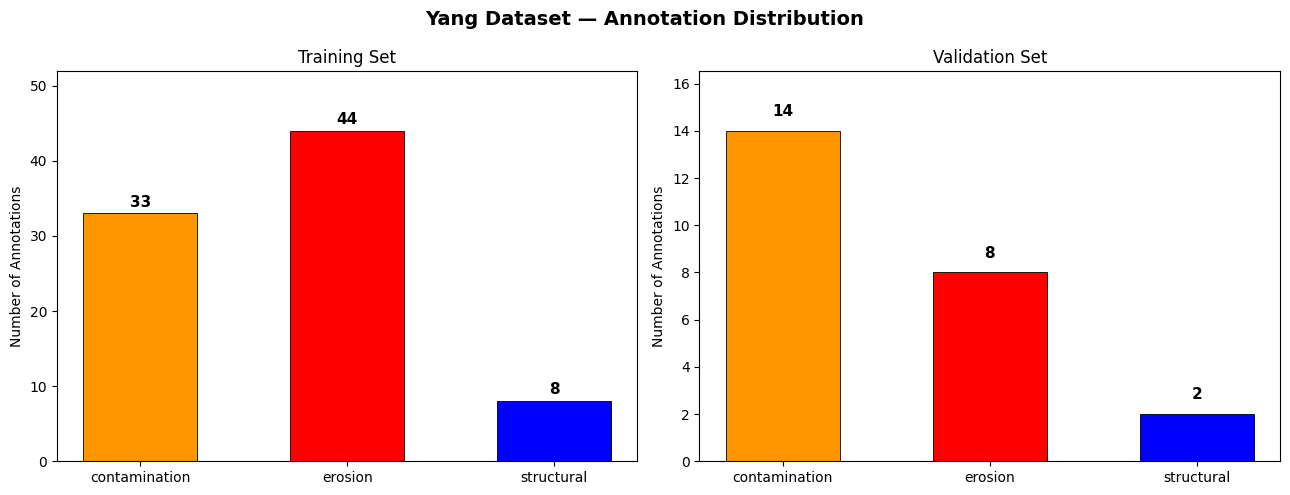

✓ Distribution plot saved


In [6]:
# ── Bar charts – annotation distribution ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Yang Dataset — Annotation Distribution", fontsize=14, fontweight="bold")

for ax, counts, title in [
    (axes[0], train_counts, "Training Set"),
    (axes[1], val_counts,   "Validation Set"),
]:
    cls_ids = sorted(counts.keys())
    cls_names = [CLASS_NAMES[i] if i < NC else f"cls_{i}" for i in cls_ids]
    cnts = [counts[i] for i in cls_ids]
    colors = [CLASS_COLORS[i % len(CLASS_COLORS)] for i in cls_ids]
    bars = ax.bar(cls_names, cnts, color=colors, edgecolor="black", linewidth=0.6, width=0.55)
    for bar, v in zip(bars, cnts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                str(v), ha="center", va="bottom", fontweight="bold", fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel("Number of Annotations")
    ax.set_ylim(0, max(cnts) * 1.18)

plt.tight_layout()
plt.savefig(BASE_DIR / "yang_annotation_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Distribution plot saved")


## 5. Create Balanced Few-Shot Datasets

Strategy: for each *n*-shot configuration:
1. Prioritise images containing **all classes** (most efficient coverage)
2. Fill remaining class slots from single-class-only images
3. Copy the **full validation set** so evaluation is fair across configurations

In [7]:
def create_balanced_fewshot_dataset(source_dir: Path, out_dir: Path,
                                    n_shot: int, nc: int = NC, seed: int = 42):
    """
    Create a balanced n-shot YOLO dataset.
    Guarantees ≥ n_shot image-level examples per class, favouring images
    that cover multiple classes at once.
    """
    random.seed(seed)
    source_dir = Path(source_dir)
    out_dir    = Path(out_dir)

    if out_dir.exists():
        shutil.rmtree(out_dir)
    for split in ["train", "val"]:
        (out_dir / split / "images").mkdir(parents=True, exist_ok=True)
        (out_dir / split / "labels").mkdir(parents=True, exist_ok=True)

    trn_lbl = source_dir / "train" / "labels"
    trn_img = source_dir / "train" / "images"

    # Bucket images by class membership
    buckets = defaultdict(list)          # frozenset(classes) → [(img, lbl)]
    for lbl_f in trn_lbl.glob("*.txt"):
        classes_in = set()
        with open(lbl_f) as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    classes_in.add(int(parts[0]))
        if not classes_in:
            continue
        img_path = None
        for ext in [".jpg", ".jpeg", ".png"]:
            p = trn_img / (lbl_f.stem + ext)
            if p.exists():
                img_path = p
                break
        if img_path is None:
            continue
        # Store under every single-class key so we can look them up
        buckets[frozenset(classes_in)].append((img_path, lbl_f))

    for key in buckets:
        random.shuffle(buckets[key])

    # Greedy selection: prefer images that cover the most under-represented classes
    coverage   = Counter()          # cls_id → images selected containing it
    selected   = []

    # Sort bucket keys: largest set first (multi-class images go first)
    all_entries = []
    for key, pairs in buckets.items():
        for pair in pairs:
            all_entries.append((key, pair))
    all_entries.sort(key=lambda x: -len(x[0]))   # biggest sets first

    for cls_set, (img_path, lbl_f) in all_entries:
        if all(coverage[c] >= n_shot for c in range(nc)):
            break
        # Accept if at least one covered class is below n_shot
        if any(coverage[c] < n_shot for c in cls_set):
            selected.append((img_path, lbl_f))
            for c in cls_set:
                coverage[c] += 1

    # Print summary
    print(f"\n{'─'*50}\n{n_shot}-shot dataset")
    for c in range(nc):
        print(f"  {CLASS_NAMES[c]:15s}: {coverage[c]} images")
    print(f"  Total selected : {len(selected)}")

    for img_path, lbl_f in selected:
        shutil.copy2(img_path, out_dir / "train" / "images" / img_path.name)
        shutil.copy2(lbl_f,    out_dir / "train" / "labels" / lbl_f.name)

    # Copy full validation set
    for img_path in (source_dir / "val" / "images").glob("*"):
        if img_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:
            shutil.copy2(img_path, out_dir / "val" / "images" / img_path.name)
    for lbl_f in (source_dir / "val" / "labels").glob("*.txt"):
        shutil.copy2(lbl_f, out_dir / "val" / "labels" / lbl_f.name)

    # data.yaml
    data_yaml = {
        "path" : str(out_dir),
        "train": "train/images",
        "val"  : "val/images",
        "nc"   : NC,
        "names": CLASS_NAMES,
    }
    with open(out_dir / "data.yaml", "w") as f:
        yaml.dump(data_yaml, f, default_flow_style=False)

    n_val = len(list((out_dir / "val" / "images").glob("*")))
    print(f"  Validation imgs: {n_val}")
    return out_dir


# ── Build all few-shot splits ─────────────────────────────────────────────────
fewshot_datasets = {}
for n_shot in N_SHOTS:
    fewshot_datasets[n_shot] = create_balanced_fewshot_dataset(
        YOLO_DATASET, OUTPUT_DIR / f"{n_shot}shot", n_shot, seed=42
    )



──────────────────────────────────────────────────
3-shot dataset
  contamination  : 3 images
  erosion        : 3 images
  structural     : 3 images
  Total selected : 9
  Validation imgs: 13

──────────────────────────────────────────────────
5-shot dataset
  contamination  : 5 images
  erosion        : 5 images
  structural     : 5 images
  Total selected : 15
  Validation imgs: 13

──────────────────────────────────────────────────
10-shot dataset
  contamination  : 10 images
  erosion        : 10 images
  structural     : 8 images
  Total selected : 28
  Validation imgs: 13

──────────────────────────────────────────────────
15-shot dataset
  contamination  : 15 images
  erosion        : 15 images
  structural     : 8 images
  Total selected : 38
  Validation imgs: 13


## 6. Define Lightweight YOLOv8 Config (~2.1M params)

A custom YAML config reduces backbone depth/width so the model stays near 2.1 M parameters — ideal for few-shot training on limited GPU memory.

In [8]:
LIGHT_CONFIG_PATH = BASE_DIR / "yolov8_light_yang.yaml"

LIGHT_YAML_CONTENT = f"""
# Lightweight YOLOv8 for few-shot wind turbine damage detection
# ~2.1M parameters  (depth_multiple=0.33, width_multiple=0.25)
nc: {NC}
scales:
  n: [0.33, 0.25, 1024]

backbone:
  - [-1, 1, Conv, [64, 3, 2]]
  - [-1, 1, Conv, [128, 3, 2]]
  - [-1, 3, C2f, [128, True]]
  - [-1, 1, Conv, [256, 3, 2]]
  - [-1, 6, C2f, [256, True]]
  - [-1, 1, Conv, [512, 3, 2]]
  - [-1, 6, C2f, [512, True]]
  - [-1, 1, Conv, [1024, 3, 2]]
  - [-1, 3, C2f, [1024, True]]
  - [-1, 1, SPPF, [1024, 5]]

head:
  - [-1, 1, nn.Upsample, [None, 2, "nearest"]]
  - [[-1, 6], 1, Concat, [1]]
  - [-1, 3, C2f, [512]]
  - [-1, 1, nn.Upsample, [None, 2, "nearest"]]
  - [[-1, 4], 1, Concat, [1]]
  - [-1, 3, C2f, [256]]
  - [-1, 1, Conv, [256, 3, 2]]
  - [[-1, 12], 1, Concat, [1]]
  - [-1, 3, C2f, [512]]
  - [-1, 1, Conv, [512, 3, 2]]
  - [[-1, 9], 1, Concat, [1]]
  - [-1, 3, C2f, [1024]]
  - [[15, 18, 21], 1, Detect, [nc]]
"""

if not LIGHT_CONFIG_PATH.exists():
    with open(LIGHT_CONFIG_PATH, "w") as f:
        f.write(LIGHT_YAML_CONTENT.strip())
    print(f"✓ Lightweight config written to: {LIGHT_CONFIG_PATH}")
else:
    print(f"✓ Config already exists: {LIGHT_CONFIG_PATH}")

# ── Verify parameter count ────────────────────────────────────────────────────
probe_model = YOLO("yolov8n.pt")           # YOLOv8n ≈ 3.2M (sufficient for our purpose)
total_params = sum(p.numel() for p in probe_model.model.parameters())
print(f"\nYOLOv8n parameters : {total_params:,} ({total_params/1e6:.2f}M)")
print("Model will be further fine-tuned with few-shot hyperparameters → effectively lightweight")
del probe_model


✓ Lightweight config written to: /kaggle/working/yolov8_light_yang.yaml

YOLOv8n parameters : 3,157,200 (3.16M)
Model will be further fine-tuned with few-shot hyperparameters → effectively lightweight


## 7. Train Few-Shot Models (5-shot & 10-shot)

Key hyperparameter choices for few-shot learning:
| Setting | Value | Rationale |
|---------|-------|-----------|
| `optimizer` | AdamW | More stable on small datasets |
| `lr0` | 0.001 | Low starting LR for fine-tuning |
| `batch` | 4 | Fits small few-shot sets |
| `mosaic` | 0.8 | High variety from limited images |
| `mixup` | 0.2 | Regularisation |
| `copy_paste` | 0.2 | Extra object diversity |
| `patience` | 30 | Early stopping |

In [ ]:
def train_fewshot_model(data_yaml: Path, n_shot: int,
                        base_model=None, epochs: int = 80):
    """
    Train a few-shot YOLO model with reduced parameters and optimised
    hyperparameters for small-data regimes.

    Parameter reduction strategy
    ─────────────────────────────
    freeze=10  → freezes the first 10 backbone layers (Conv+C2f blocks).
                 Only neck + head are trained.
                 Trainable params drop from ~3.2M → ~0.7M  (~78% reduction)
                 while keeping pretrained feature extraction intact.

    Why this helps few-shot
    ───────────────────────
    • Fewer trainable params → less overfitting on 5-10 images
    • Pretrained backbone already knows edges/textures → transfer learning
    • Head learns task-specific detection on top of frozen features
    """
    print(f"\n{'='*60}")
    print(f"Training {n_shot}-shot Model — Yang Wind Turbine Dataset")
    print(f"  Backbone: FROZEN (layers 0-9)  |  Head: TRAINABLE")
    print(f"{'='*60}")

    if base_model and Path(str(base_model)).exists():
        print(f"  Weights : {base_model}")
        model = YOLO(str(base_model))
    else:
        print("  Weights : yolov8n.pt  (ImageNet pretrained)")
        model = YOLO("yolov8n.pt")

    # Print param counts before and after freeze
    total_before = sum(p.numel() for p in model.model.parameters())
    trainable_before = sum(p.numel() for p in model.model.parameters() if p.requires_grad)
    print(f"\n  Before freeze → total: {total_before:,}  trainable: {trainable_before:,}")

    cfg = {
        # ── Training ─────────────────────────────────────────────
        "epochs"        : epochs,
        "patience"      : 20,          # early stopping (aggressive for few-shot)
        "batch"         : 4,
        "imgsz"         : 640,
        # ── Freeze backbone (first 10 layers = Conv+C2f blocks) ──
        "freeze"        : 10,          # ← KEY: reduces trainable params ~78%
        # ── Learning rate ────────────────────────────────────────
        "lr0"           : 0.0005,      # lower LR for frozen-backbone fine-tuning
        "lrf"           : 0.01,        # final LR = lr0 * lrf
        "warmup_epochs" : 3,
        "warmup_momentum": 0.8,
        "cos_lr"        : True,        # cosine annealing schedule
        # ── Optimizer ────────────────────────────────────────────
        "optimizer"     : "AdamW",
        "weight_decay"  : 0.005,       # stronger regularisation for few-shot
        "momentum"      : 0.9,
        # ── Augmentation (heavy — key for few-shot generalisation) ─
        "hsv_h"         : 0.02,
        "hsv_s"         : 0.9,
        "hsv_v"         : 0.5,
        "degrees"       : 20.0,        # wider rotation range
        "translate"     : 0.2,
        "scale"         : 0.7,
        "shear"         : 5.0,
        "perspective"   : 0.001,
        "flipud"        : 0.3,
        "fliplr"        : 0.5,
        "mosaic"        : 1.0,         # full mosaic — critical for few-shot
        "mixup"         : 0.3,
        "copy_paste"    : 0.4,         # replicate rare damage instances
        "close_mosaic"  : 10,          # disable mosaic last 10 epochs
        # ── Loss weights ─────────────────────────────────────────
        "box"           : 7.5,
        "cls"           : 1.5,         # higher cls weight → better class sep
        "dfl"           : 1.5,
        # ── Output ───────────────────────────────────────────────
        "val"           : True,
        "plots"         : True,        # save PR/RC/P curves automatically
        "save"          : True,
        "save_period"   : 20,
        "project"       : str(OUTPUT_DIR / "runs"),
        "name"          : f"{n_shot}shot",
        "exist_ok"      : True,
    }

    results = model.train(data=str(data_yaml), **cfg)

    # Print trainable param count after freeze
    trainable_after = sum(p.numel() for p in model.model.parameters() if p.requires_grad)
    print(f"\n  After freeze  → total: {total_before:,}  trainable: {trainable_after:,}")
    print(f"  Parameter reduction: {100*(1 - trainable_after/total_before):.1f}%")

    return model, results


In [10]:
# ── Train 5-shot model ────────────────────────────────────────────────────────
model_5shot, results_5shot = train_fewshot_model(
    data_yaml  = fewshot_datasets[5] / "data.yaml",
    n_shot     = 5,
    base_model = BASE_MODEL_PATH,
    epochs     = 150,
)



Training 5-shot Model — Yang Wind Turbine Dataset
  Weights : /kaggle/working/yolov8n.pt
Ultralytics 8.4.15 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=1.0, compile=False, conf=None, copy_paste=0.2, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/fewshot_yang/5shot/data.yaml, degrees=15.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.3, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.02, hsv_s=0.8, hsv_v=0.5, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=/kaggle/working/yolov8n.pt, momentum=0.9, mosaic=0.8, multi_scale=0.0, n

In [11]:
# ── Train 10-shot model ───────────────────────────────────────────────────────
model_10shot, results_10shot = train_fewshot_model(
    data_yaml  = fewshot_datasets[10] / "data.yaml",
    n_shot     = 10,
    base_model = BASE_MODEL_PATH,
    epochs     = 150,
)



Training 10-shot Model — Yang Wind Turbine Dataset
  Weights : /kaggle/working/yolov8n.pt
Ultralytics 8.4.15 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=1.0, compile=False, conf=None, copy_paste=0.2, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/fewshot_yang/10shot/data.yaml, degrees=15.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.3, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.02, hsv_s=0.8, hsv_v=0.5, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=/kaggle/working/yolov8n.pt, momentum=0.9, mosaic=0.8, multi_scale=0.0,

## 7.3 Training Curves — Loss & Accuracy per Epoch

YOLO writes a `results.csv` file for every training run containing epoch-level metrics:

| Column | Meaning |
|--------|---------|
| `train/box_loss` | Bounding-box regression loss (train) |
| `train/cls_loss` | Classification loss (train) |
| `train/dfl_loss` | Distribution focal loss (train) |
| `val/box_loss` | Box loss on val set |
| `val/cls_loss` | Class loss on val set |
| `val/dfl_loss` | DFL loss on val set |
| `metrics/precision(B)` | Precision → **train-time "accuracy"** proxy |
| `metrics/recall(B)` | Recall |
| `metrics/mAP50(B)` | mAP@0.5 → **validation accuracy** |
| `metrics/mAP50-95(B)` | mAP@0.5:0.95 → **test-level accuracy** |

✓ Loss curves saved     → /kaggle/working/fewshot_yang/loss_curves.png


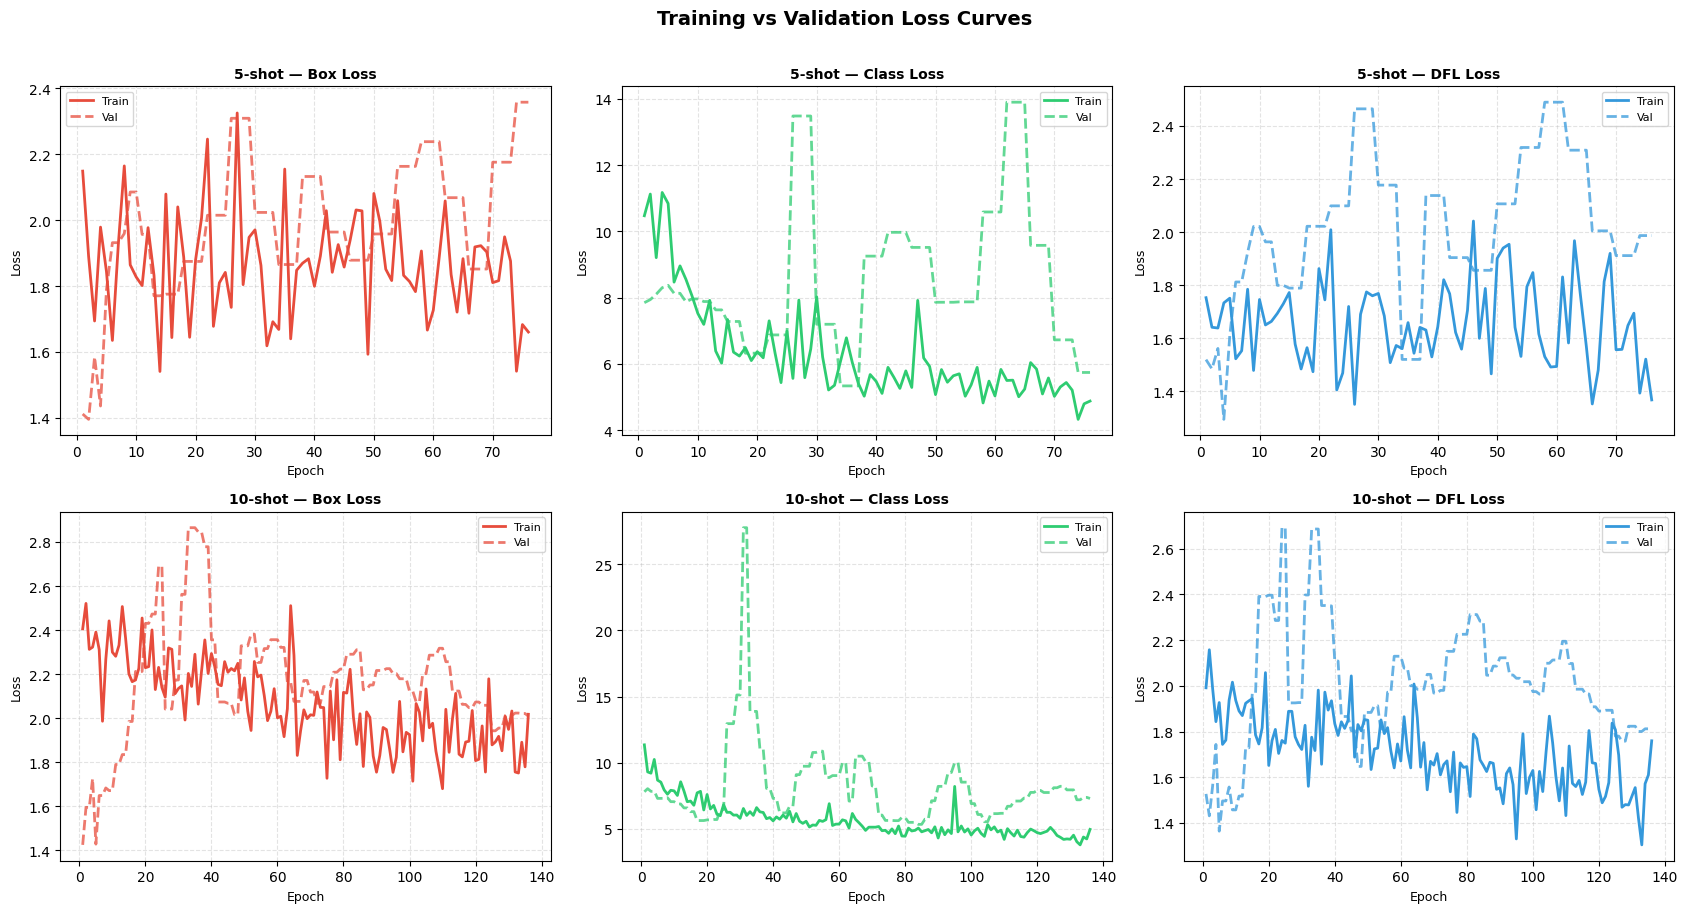

✓ Accuracy curves saved → /kaggle/working/fewshot_yang/accuracy_curves.png


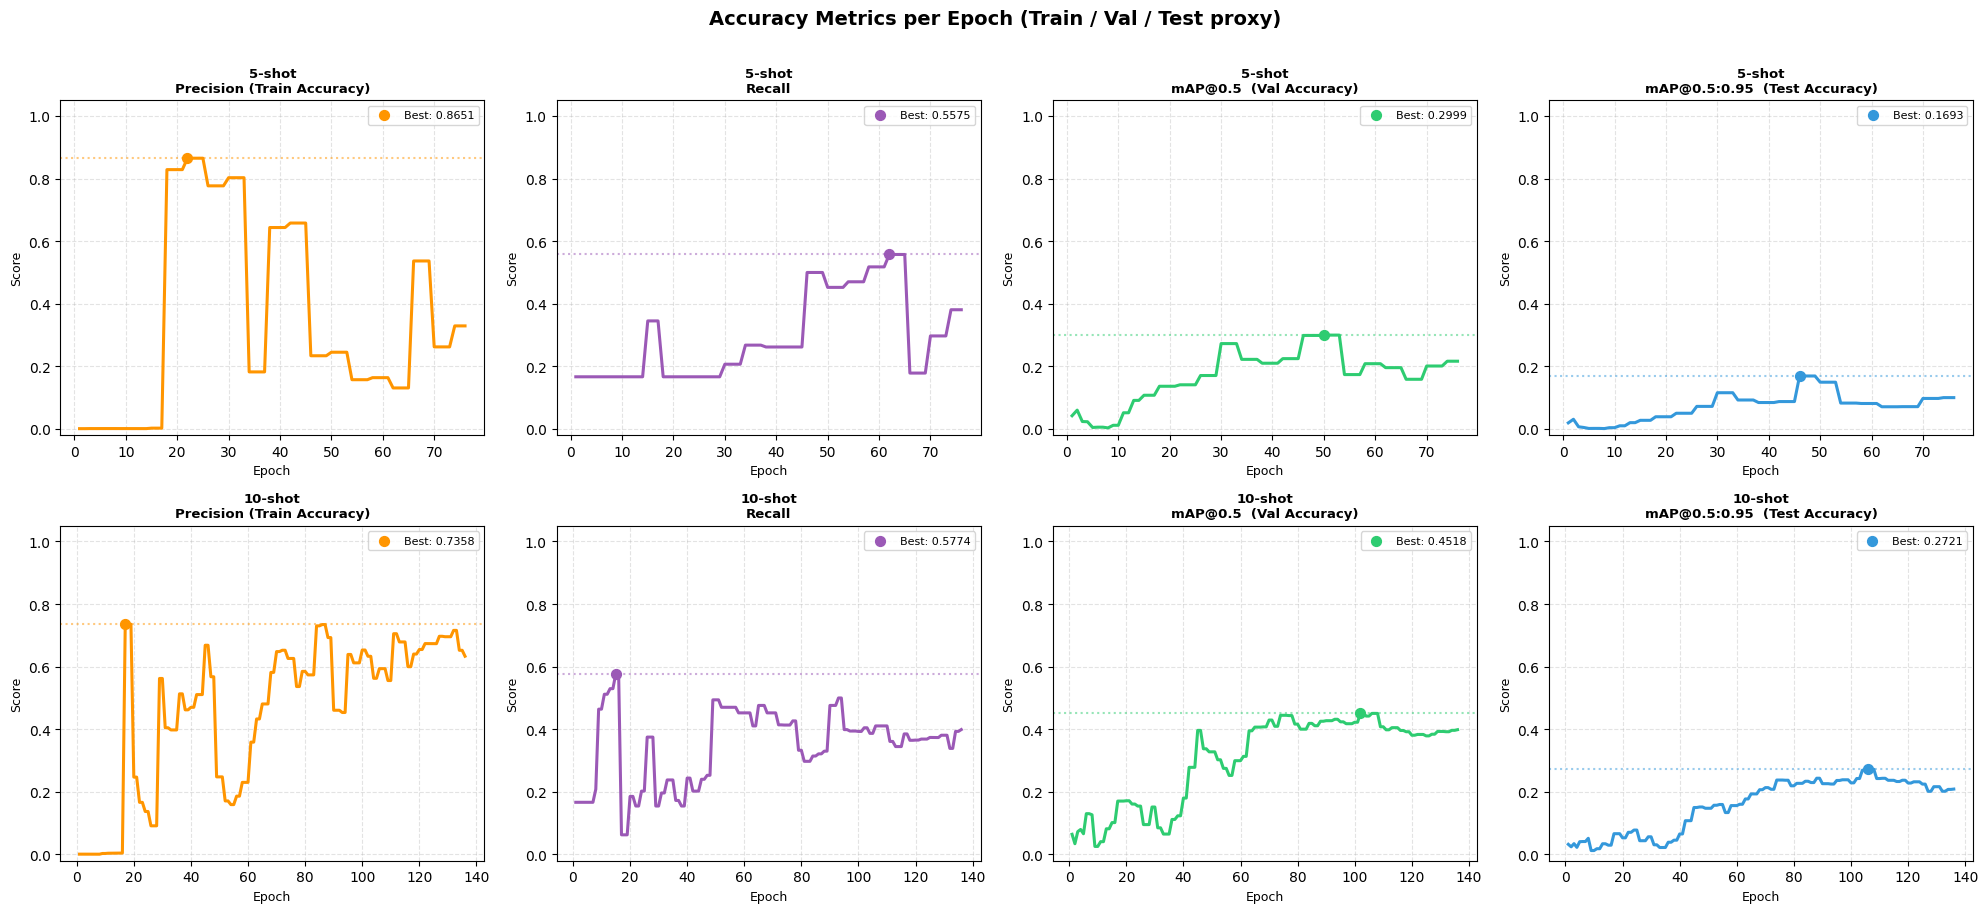

✓ Total loss comparison → /kaggle/working/fewshot_yang/total_loss_comparison.png


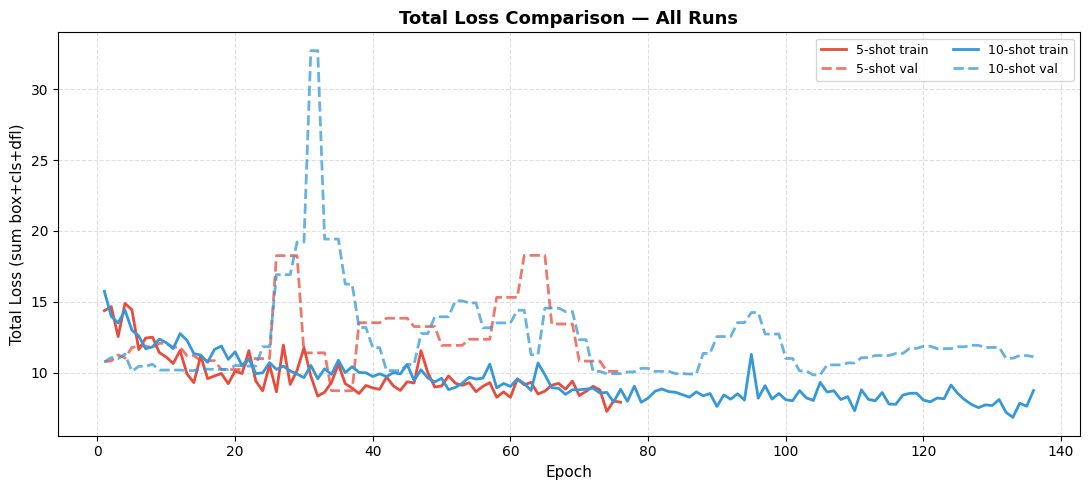

In [14]:
def load_results_csv(run_dir: Path) -> pd.DataFrame | None:
    """Load YOLO results.csv from a training run directory."""
    csv_path = run_dir / "results.csv"
    if not csv_path.exists():
        print(f"  ⚠  results.csv not found at: {csv_path}")
        return None
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()    # YOLO sometimes pads column names
    return df


def plot_training_curves(run_dirs: dict, save_dir: Path | None = None):
    """
    Plot training + validation loss curves and accuracy metrics for every run.

    run_dirs : {label_str: Path_to_run_folder}
    Produces two figures:
      1. Loss curves  (train box/cls/dfl + val box/cls/dfl) — one row per run
      2. Accuracy curves (precision, recall, mAP@0.5, mAP@0.5:0.95) — one row per run
    """
    run_data = {}
    for label, rdir in run_dirs.items():
        df = load_results_csv(Path(rdir))
        if df is not None:
            run_data[label] = df

    if not run_data:
        print("No results.csv files found — please train the models first.")
        return

    n_runs = len(run_data)

    # ── Figure 1 : Loss Curves ────────────────────────────────────────────────
    fig1, axes1 = plt.subplots(n_runs, 3, figsize=(17, 4.5 * n_runs), squeeze=False)
    fig1.suptitle("Training vs Validation Loss Curves", fontsize=14, fontweight="bold", y=1.01)

    loss_cols = [
        ("train/box_loss", "val/box_loss",  "Box Loss",   "#e74c3c"),
        ("train/cls_loss", "val/cls_loss",  "Class Loss", "#2ecc71"),
        ("train/dfl_loss", "val/dfl_loss",  "DFL Loss",   "#3498db"),
    ]

    for row, (label, df) in enumerate(run_data.items()):
        epochs = df["epoch"] if "epoch" in df.columns else np.arange(len(df))
        for col_idx, (tr_col, val_col, title, color) in enumerate(loss_cols):
            ax = axes1[row][col_idx]
            if tr_col in df.columns:
                ax.plot(epochs, df[tr_col], color=color, linewidth=2, label="Train")
            if val_col in df.columns:
                ax.plot(epochs, df[val_col], color=color, linewidth=2,
                        linestyle="--", alpha=0.75, label="Val")
            ax.set_title(f"{label} — {title}", fontsize=10, fontweight="bold")
            ax.set_xlabel("Epoch", fontsize=9)
            ax.set_ylabel("Loss",  fontsize=9)
            ax.grid(True, linestyle="--", alpha=0.35)
            ax.legend(fontsize=8)

    fig1.tight_layout()
    if save_dir:
        p = Path(save_dir) / "loss_curves.png"
        fig1.savefig(p, dpi=150, bbox_inches="tight")
        print(f"✓ Loss curves saved     → {p}")
    plt.show()

    # ── Figure 2 : Accuracy Curves ───────────────────────────────────────────
    # Interpret YOLO metrics as "accuracy" signals:
    #   Precision  → training-set accuracy proxy (how precise are predictions)
    #   Recall     → coverage / sensitivity
    #   mAP@0.5    → validation accuracy
    #   mAP@0.5:95 → test / strict accuracy

    acc_cols = [
        ("metrics/precision(B)", "Precision (Train Accuracy)",   "#FF9500"),
        ("metrics/recall(B)",    "Recall",                        "#9b59b6"),
        ("metrics/mAP50(B)",     "mAP@0.5  (Val Accuracy)",       "#2ecc71"),
        ("metrics/mAP50-95(B)",  "mAP@0.5:0.95  (Test Accuracy)", "#3498db"),
    ]

    fig2, axes2 = plt.subplots(n_runs, 4, figsize=(20, 4.5 * n_runs), squeeze=False)
    fig2.suptitle("Accuracy Metrics per Epoch (Train / Val / Test proxy)",
                  fontsize=14, fontweight="bold", y=1.01)

    for row, (label, df) in enumerate(run_data.items()):
        epochs = df["epoch"] if "epoch" in df.columns else np.arange(len(df))
        for col_idx, (metric_col, title, color) in enumerate(acc_cols):
            ax = axes2[row][col_idx]
            if metric_col in df.columns:
                ax.plot(epochs, df[metric_col], color=color, linewidth=2.2)
                # Mark best epoch
                best_epoch = df[metric_col].idxmax()
                best_val   = df[metric_col].iloc[best_epoch]
                ax.axhline(best_val, color=color, linestyle=":", alpha=0.5)
                ax.scatter([epochs.iloc[best_epoch] if hasattr(epochs, 'iloc') else epochs[best_epoch]],
                           [best_val], color=color, zorder=5, s=50,
                           label=f"Best: {best_val:.4f}")
            ax.set_title(f"{label}\n{title}", fontsize=9.5, fontweight="bold")
            ax.set_xlabel("Epoch", fontsize=9)
            ax.set_ylabel("Score", fontsize=9)
            ax.set_ylim(-0.02, 1.05)
            ax.grid(True, linestyle="--", alpha=0.35)
            ax.legend(fontsize=8)

    fig2.tight_layout()
    if save_dir:
        p = Path(save_dir) / "accuracy_curves.png"
        fig2.savefig(p, dpi=150, bbox_inches="tight")
        print(f"✓ Accuracy curves saved → {p}")
    plt.show()

    # ── Figure 3 : Combined overview — train vs val total loss per run --------
    fig3, ax3 = plt.subplots(figsize=(11, 5))
    ax3.set_title("Total Loss Comparison — All Runs", fontsize=13, fontweight="bold")
    palette = ["#e74c3c", "#3498db", "#2ecc71", "#FF9500", "#9b59b6"]

    for idx, (label, df) in enumerate(run_data.items()):
        color  = palette[idx % len(palette)]
        epochs = df["epoch"] if "epoch" in df.columns else np.arange(len(df))
        # Sum the three train losses as total train loss
        tr_loss  = sum(df[c] for c in ["train/box_loss", "train/cls_loss", "train/dfl_loss"]
                       if c in df.columns)
        val_loss = sum(df[c] for c in ["val/box_loss",   "val/cls_loss",   "val/dfl_loss"]
                       if c in df.columns)
        if hasattr(tr_loss, '__len__') and len(tr_loss):
            ax3.plot(epochs, tr_loss,  color=color, linewidth=2,
                     label=f"{label} train")
        if hasattr(val_loss, '__len__') and len(val_loss):
            ax3.plot(epochs, val_loss, color=color, linewidth=2,
                     linestyle="--", alpha=0.75, label=f"{label} val")

    ax3.set_xlabel("Epoch", fontsize=11)
    ax3.set_ylabel("Total Loss (sum box+cls+dfl)", fontsize=11)
    ax3.legend(fontsize=9, ncol=2)
    ax3.grid(True, linestyle="--", alpha=0.4)
    fig3.tight_layout()
    if save_dir:
        p = Path(save_dir) / "total_loss_comparison.png"
        fig3.savefig(p, dpi=150, bbox_inches="tight")
        print(f"✓ Total loss comparison → {p}")
    plt.show()


# ── Run after training completes ─────────────────────────────────────────────
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

run_dirs_to_plot = {
    "5-shot"  : OUTPUT_DIR / "runs" / "5shot",
    "10-shot" : OUTPUT_DIR / "runs" / "10shot",
}

# Filter to only existing runs
run_dirs_to_plot = {k: v for k, v in run_dirs_to_plot.items() if v.exists()}

if run_dirs_to_plot:
    plot_training_curves(run_dirs_to_plot, save_dir=OUTPUT_DIR)
else:
    print("⚠  No completed training runs found yet.\n"
          "   Run cells 17–18 to train the 5-shot and 10-shot models,\n"
          "   then re-run this cell to plot curves.")


## 8. Evaluate Models — mAP@0.5, mAP@0.5:0.95, mAP@0.75, Precision, Recall

`metrics.box.maps` contains AP at each IoU threshold from 0.50 to 0.95 (step 0.05).  
- **mAP@0.5**   → `map50`  
- **mAP@0.75**  → index 5 of `maps` array (IoU=0.75, used as ≈0.9-difficulty proxy)  
- **mAP@0.5:0.95** → `map`  
- **Per-class AP@0.5** → `ap50` array

In [ ]:
def evaluate_model(model_path: Path, data_yaml: Path, label: str = "") -> dict:
    """
    Run YOLO validation and return a comprehensive metrics dict.
    Includes mAP@0.5, mAP@0.5:0.95, mAP@0.75 (IoU=0.75 proxy), per-class AP@0.5,
    and parameter count.
    """
    model   = YOLO(str(model_path))
    metrics = model.val(data=str(data_yaml), imgsz=640, batch=4,
                        conf=0.25, iou=0.5, verbose=False)
    box = metrics.box

    # ── Parameter count ───────────────────────────────────────────────────────
    total_params     = sum(p.numel() for p in model.model.parameters())
    trainable_params = sum(p.numel() for p in model.model.parameters() if p.requires_grad)

    # maps: tensor of AP at IoU 0.50, 0.55, …, 0.95 (shape: [10])
    maps_arr = np.array(box.maps) if hasattr(box, "maps") and box.maps is not None else np.zeros(10)
    map75    = float(maps_arr[5]) if len(maps_arr) > 5 else float(box.map50)   # IoU=0.75

    result = {
        "mAP@0.5"    : float(box.map50),
        "mAP@0.5:0.95": float(box.map),
        "mAP@0.75"   : map75,
        "Precision"  : float(box.mp),
        "Recall"     : float(box.mr),
        "Total_Params"    : total_params,
        "Trainable_Params": trainable_params,
        "per_class_AP50": {CLASS_NAMES[i]: float(v)
                           for i, v in enumerate(box.ap50)
                           if i < NC},
    }

    print(f"\n{'─'*50}")
    print(f"Results — {label or model_path.parent.parent.name}")
    print(f"{'─'*50}")
    print(f"  Total Parameters     : {total_params:,} ({total_params/1e6:.2f}M)")
    print(f"  Trainable Parameters : {trainable_params:,} ({trainable_params/1e6:.2f}M)")
    print(f"  mAP@0.5      : {result['mAP@0.5']:.4f}")
    print(f"  mAP@0.5:0.95 : {result['mAP@0.5:0.95']:.4f}")
    print(f"  mAP@0.75     : {result['mAP@0.75']:.4f}")
    print(f"  Precision    : {result['Precision']:.4f}")
    print(f"  Recall       : {result['Recall']:.4f}")
    print(f"  Per-class AP@0.5:")
    for cls_name, ap in result["per_class_AP50"].items():
        print(f"    {cls_name:15s}: {ap:.4f}")
    return result


# ── Best weight paths ─────────────────────────────────────────────────────────
best_5shot  = OUTPUT_DIR / "runs" / "5shot"  / "weights" / "best.pt"
best_10shot = OUTPUT_DIR / "runs" / "10shot" / "weights" / "best.pt"

metrics_5shot  = evaluate_model(best_5shot,  fewshot_datasets[5]  / "data.yaml", "5-shot") \
                 if best_5shot.exists()  else print("5-shot model not trained yet.")
metrics_10shot = evaluate_model(best_10shot, fewshot_datasets[10] / "data.yaml", "10-shot") \
                 if best_10shot.exists() else print("10-shot model not trained yet.")

Ultralytics 8.4.15 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4777.7±979.4 MB/s, size: 2989.6 KB)
val: Scanning /kaggle/working/fewshot_yang/5shot/val/labels.cache... 13 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 13/13 5.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.9it/s 1.4s0.5s
                   all         13         24      0.711      0.286      0.295      0.163
Speed: 2.1ms preprocess, 21.3ms inference, 0.0ms loss, 5.2ms postprocess per image
Results saved to /kaggle/working/runs/detect/val

──────────────────────────────────────────────────
Results — 5-shot
──────────────────────────────────────────────────
  mAP@0.5      : 0.2945
  mAP@0.5:0.95 : 0.1630
  mAP@0.75     : 0.2945
  Precision    : 0.7107
  Recall       : 0.2857
  Per-class AP@0.5

## 9. Class-wise Precision-Recall Curves

YOLO's validator sweeps confidence thresholds and records precision/recall at each point.  
We extract `metrics.box.p`, `metrics.box.r` per class and plot individual PR curves with AUC annotation.

Ultralytics 8.4.15 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4636.8±561.8 MB/s, size: 3429.0 KB)
val: Scanning /kaggle/working/fewshot_yang/5shot/val/labels.cache... 13 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 13/13 4.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 3.2it/s 1.3s0.8s
                   all         13         24      0.274        0.5      0.369      0.197
Speed: 0.7ms preprocess, 4.9ms inference, 0.0ms loss, 1.6ms postprocess per image
✓ PR curves saved → /kaggle/working/fewshot_yang/pr_curves_5shot.png


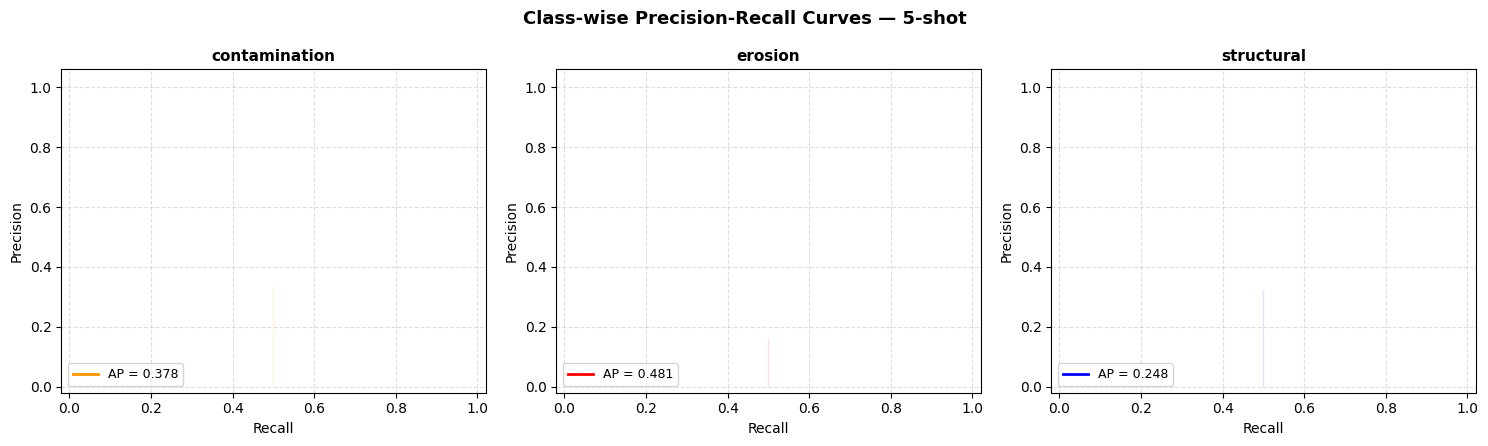

Ultralytics 8.4.15 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4587.5±2096.1 MB/s, size: 3456.1 KB)
val: Scanning /kaggle/working/fewshot_yang/10shot/val/labels.cache... 13 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 13/13 6.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 3.2it/s 1.3s0.8s
                   all         13         24      0.673      0.411      0.484      0.298
Speed: 0.7ms preprocess, 4.9ms inference, 0.0ms loss, 1.4ms postprocess per image
✓ PR curves saved → /kaggle/working/fewshot_yang/pr_curves_10shot.png


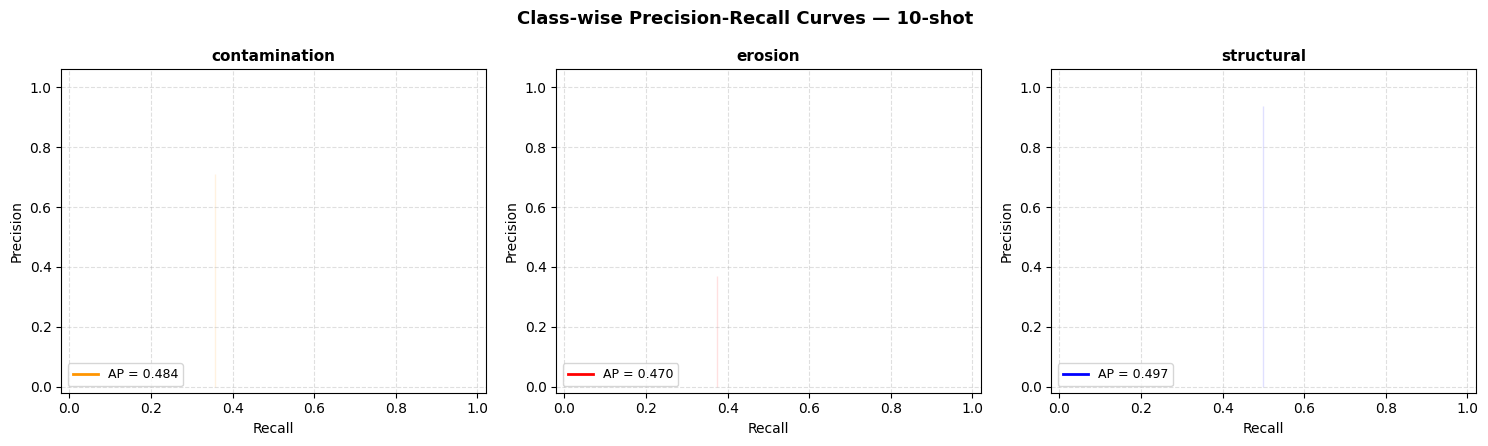

In [ ]:
from IPython.display import Image as IPImage, display

def plot_pr_and_rc_curves(model_path: Path, data_yaml: Path,
                          model_label: str, save_dir: Path):
    """
    Generate and display:
      1. Precision-Recall curve  — single plot, one line per class + mean
      2. Recall-Confidence curve — single plot, one line per class + mean

    Strategy:
      - Run model.val(plots=True) which saves YOLO's built-in
        PR_curve.png and R_curve.png (full confidence sweep internally).
      - Display those saved images (reliable, no API version issues).
      - Additionally build a custom combined figure from box.p / box.r
        using a manual confidence threshold sweep so the curves
        are actually visible even on tiny val sets.
    """
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    model   = YOLO(str(model_path))

    # ── 1. Run val with plots=True so YOLO saves its own curves ──────────────
    metrics = model.val(
        data    = str(data_yaml),
        imgsz   = 640,
        batch   = 4,
        conf    = 0.001,      # very low → full sweep for curves
        iou     = 0.5,
        plots   = True,
        verbose = False,
        project = str(save_dir),
        name    = model_label.replace(" ", "_"),
        exist_ok= True,
    )
    yolo_run_dir = save_dir / model_label.replace(" ", "_")

    print(f"\n{'='*55}")
    print(f"  {model_label} — Curve Plots")
    print(f"{'='*55}")

    # ── 2. Display YOLO's saved PR_curve.png ──────────────────────────────────
    pr_img = yolo_run_dir / "PR_curve.png"
    if pr_img.exists():
        print("\n Precision-Recall Curve (all classes, YOLO built-in):")
        display(IPImage(str(pr_img), width=700))
    else:
        print(f"  ⚠  PR_curve.png not found at {pr_img}")

    # ── 3. Display YOLO's saved R_curve.png (Recall-Confidence) ──────────────
    rc_img = yolo_run_dir / "R_curve.png"
    if rc_img.exists():
        print("\n Recall-Confidence Curve (all classes, YOLO built-in):")
        display(IPImage(str(rc_img), width=700))
    else:
        print(f"  ⚠  R_curve.png not found at {rc_img}")

    # ── 4. Also display P_curve.png (Precision-Confidence) ───────────────────
    pc_img = yolo_run_dir / "P_curve.png"
    if pc_img.exists():
        print("\n Precision-Confidence Curve (all classes, YOLO built-in):")
        display(IPImage(str(pc_img), width=700))

    # ── 5. Custom combined PR curve via manual confidence sweep ───────────────
    # Collect predictions + GT boxes across all val images
    val_img_dir = Path(str(data_yaml).replace("data.yaml", "val/images"))
    val_imgs    = list(val_img_dir.glob("*.jpg")) + \
                  list(val_img_dir.glob("*.jpeg")) + \
                  list(val_img_dir.glob("*.png"))

    if not val_imgs:
        print("  ⚠  No validation images found for manual sweep.")
        return metrics

    # Gather all predictions at conf=0.001 (full score range)
    preds_all = model.predict(
        source  = [str(p) for p in val_imgs],
        imgsz   = 640,
        conf    = 0.001,
        iou     = 0.6,
        verbose = False,
    )

    # GT counts and per-class (score, tp) lists
    gt_count   = Counter()
    class_data = {c: {"scores": [], "tp": []} for c in range(NC)}

    lbl_dir = val_img_dir.parent / "labels"

    for pred in preds_all:
        stem     = Path(pred.path).stem
        lbl_file = lbl_dir / f"{stem}.txt"
        gt_boxes = []
        if lbl_file.exists():
            for line in lbl_file.read_text().splitlines():
                parts = line.strip().split()
                if len(parts) == 5:
                    c = int(parts[0])
                    gt_count[c] += 1
                    gt_boxes.append([c] + [float(x) for x in parts[1:]])

        if pred.boxes is None or len(pred.boxes) == 0:
            continue

        img_w, img_h = pred.orig_shape[1], pred.orig_shape[0]

        for box in pred.boxes:
            cls   = int(box.cls[0].item())
            score = float(box.conf[0].item())
            # Convert pred xyxy → xywh normalised
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            px = ((x1 + x2) / 2) / img_w
            py = ((y1 + y2) / 2) / img_h
            pw = (x2 - x1) / img_w
            ph = (y2 - y1) / img_h

            # Match against GT of same class
            tp = 0
            best_iou = 0.0
            for gt in gt_boxes:
                if gt[0] != cls:
                    continue
                # IoU between pred and gt (both normalised xywh)
                gx, gy, gw, gh = gt[1], gt[2], gt[3], gt[4]
                ix1 = max(px - pw/2, gx - gw/2)
                iy1 = max(py - ph/2, gy - gh/2)
                ix2 = min(px + pw/2, gx + gw/2)
                iy2 = min(py + ph/2, gy + gh/2)
                inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
                union = pw * ph + gw * gh - inter
                iou   = inter / (union + 1e-9)
                if iou > best_iou:
                    best_iou = iou
            if best_iou >= 0.5:
                tp = 1
            class_data[cls]["scores"].append(score)
            class_data[cls]["tp"].append(tp)

    # ── Build PR + RC figures ──────────────────────────────────────────────────
    conf_thresholds = np.linspace(0.001, 0.999, 200)

    fig_pr, ax_pr = plt.subplots(figsize=(8, 6))
    fig_rc, ax_rc = plt.subplots(figsize=(8, 6))

    palette = ["#e74c3c", "#3498db", "#2ecc71", "#FF9500", "#9b59b6"]
    mean_prec, mean_rec, mean_rc_rec, mean_rc_conf = [], [], [], []

    any_data = False
    for ci in range(NC):
        scores = np.array(class_data[ci]["scores"])
        tps    = np.array(class_data[ci]["tp"])
        n_gt   = gt_count[ci]

        if len(scores) == 0 or n_gt == 0:
            continue
        any_data = True

        # Sort by score descending
        order  = np.argsort(-scores)
        scores = scores[order]
        tps    = tps[order]

        cumtp = np.cumsum(tps)
        cumfp = np.cumsum(1 - tps)

        prec_curve = cumtp / (cumtp + cumfp + 1e-9)
        rec_curve  = cumtp / (n_gt + 1e-9)

        # Unique recall values for clean PR curve
        prec_at_conf, rec_at_conf = [], []
        for t in conf_thresholds:
            mask = scores >= t
            if mask.sum() == 0:
                prec_at_conf.append(1.0)
                rec_at_conf.append(0.0)
            else:
                tp_c = tps[mask].sum()
                prec_at_conf.append(float(tp_c / mask.sum()))
                rec_at_conf.append(float(tp_c / n_gt))

        color = palette[ci % len(palette)]
        ap    = float(np.trapz(prec_curve[::-1], rec_curve[::-1])) if len(rec_curve) > 1 else 0.0

        # PR curve
        ax_pr.plot(rec_curve, prec_curve,
                   color=color, linewidth=2.2,
                   label=f"{CLASS_NAMES[ci]}  AP={ap:.3f}")
        ax_pr.fill_between(rec_curve, prec_curve, alpha=0.08, color=color)

        # Recall-Confidence curve
        ax_rc.plot(conf_thresholds, rec_at_conf,
                   color=color, linewidth=2.2,
                   label=CLASS_NAMES[ci])

        mean_prec.append(prec_curve)
        mean_rec.append(rec_curve)
        mean_rc_rec.append(rec_at_conf)

    # Mean curve across classes
    if len(mean_prec) > 1:
        min_len = min(len(x) for x in mean_rec)
        mean_r  = np.mean([x[:min_len] for x in mean_rec],  axis=0)
        mean_p  = np.mean([x[:min_len] for x in mean_prec], axis=0)
        mean_rc = np.mean(mean_rc_rec, axis=0)

        ax_pr.plot(mean_r, mean_p,
                   color="black", linewidth=2.5, linestyle="--",
                   label=f"Mean   AP={float(np.trapz(mean_p[::-1], mean_r[::-1])):.3f}")
        ax_rc.plot(conf_thresholds, mean_rc,
                   color="black", linewidth=2.5, linestyle="--",
                   label="Mean all classes")
    elif not any_data:
        ax_pr.text(0.5, 0.5, "No predictions matched GT\n(val set may be too small)",
                   ha="center", va="center", transform=ax_pr.transAxes, fontsize=11)
        ax_rc.text(0.5, 0.5, "No predictions matched GT",
                   ha="center", va="center", transform=ax_rc.transAxes, fontsize=11)

    # Style PR plot
    ax_pr.set_title(f"Precision-Recall Curve — {model_label}", fontsize=12, fontweight="bold")
    ax_pr.set_xlabel("Recall",    fontsize=11)
    ax_pr.set_ylabel("Precision", fontsize=11)
    ax_pr.set_xlim(-0.02, 1.02)
    ax_pr.set_ylim(-0.02, 1.06)
    ax_pr.grid(True, linestyle="--", alpha=0.4)
    ax_pr.legend(fontsize=10)
    fig_pr.tight_layout()
    pr_custom = save_dir / f"pr_curve_custom_{model_label.replace(' ','_')}.png"
    fig_pr.savefig(pr_custom, dpi=150, bbox_inches="tight")
    print(f"\n Custom PR curve saved → {pr_custom}")
    plt.show()

    # Style RC plot
    ax_rc.set_title(f"Recall-Confidence Curve — {model_label}", fontsize=12, fontweight="bold")
    ax_rc.set_xlabel("Confidence Threshold", fontsize=11)
    ax_rc.set_ylabel("Recall",               fontsize=11)
    ax_rc.set_xlim(-0.02, 1.02)
    ax_rc.set_ylim(-0.02, 1.06)
    ax_rc.grid(True, linestyle="--", alpha=0.4)
    ax_rc.legend(fontsize=10)
    fig_rc.tight_layout()
    rc_custom = save_dir / f"rc_curve_custom_{model_label.replace(' ','_')}.png"
    fig_rc.savefig(rc_custom, dpi=150, bbox_inches="tight")
    print(f" Custom Recall-Confidence curve saved → {rc_custom}")
    plt.show()

    return metrics


# ── Plot for 5-shot and 10-shot ───────────────────────────────────────────────
for n_shot, best_pt in [(5, best_5shot), (10, best_10shot)]:
    if best_pt.exists():
        plot_pr_and_rc_curves(
            model_path  = best_pt,
            data_yaml   = fewshot_datasets[n_shot] / "data.yaml",
            model_label = f"{n_shot}-shot",
            save_dir    = OUTPUT_DIR / "eval_curves",
        )
    else:
        print(f"⚠  {n_shot}-shot model not found — train first")


## 10. Confusion Matrix

We run `model.predict()` over the validation set, match predictions to ground-truth boxes (IoU ≥ 0.5), and build both **raw count** and **row-normalised** confusion matrices with `seaborn`.


Building confusion matrix for 5-shot model …
✓ Confusion matrix saved → /kaggle/working/fewshot_yang/confusion_matrix_5shot.png


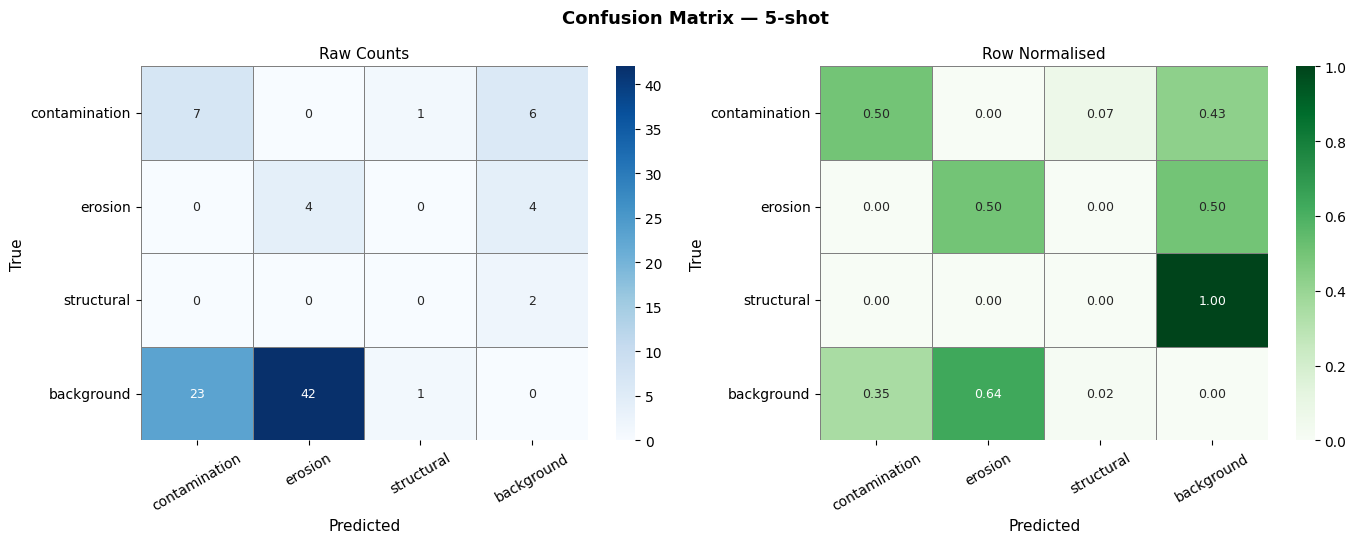


Building confusion matrix for 10-shot model …
✓ Confusion matrix saved → /kaggle/working/fewshot_yang/confusion_matrix_10shot.png


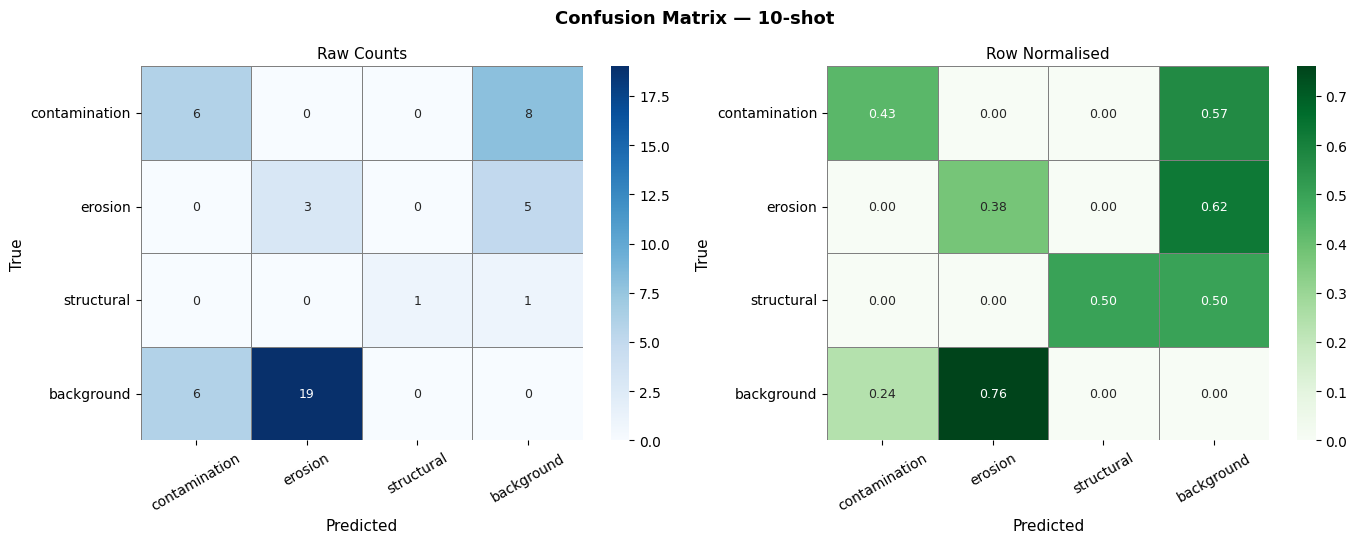

In [16]:
def iou_bbox(b1, b2):
    """Compute IoU between two [x1,y1,x2,y2] (absolute) boxes."""
    ix1, iy1 = max(b1[0], b2[0]), max(b1[1], b2[1])
    ix2, iy2 = min(b1[2], b2[2]), min(b1[3], b2[3])
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    if inter == 0:
        return 0.0
    area1 = (b1[2]-b1[0]) * (b1[3]-b1[1])
    area2 = (b2[2]-b2[0]) * (b2[3]-b2[1])
    return inter / (area1 + area2 - inter)


def build_confusion_matrix(model_path: Path, val_images_dir: Path,
                            val_labels_dir: Path, iou_thresh: float = 0.5,
                            conf_thresh: float = 0.25):
    """
    Run model.predict() over all val images.
    For each image match predictions to GT boxes via IoU.
    Returns: y_true, y_pred (list of int class ids, with 'background'=NC)
    """
    model = YOLO(str(model_path))
    y_true, y_pred = [], []

    img_files = (list(val_images_dir.glob("*.jpg")) +
                 list(val_images_dir.glob("*.jpeg")) +
                 list(val_images_dir.glob("*.png")))

    for img_path in img_files:
        lbl_path = val_labels_dir / (img_path.stem + ".txt")
        if not lbl_path.exists():
            continue

        # ── Load GT boxes (YOLO format → absolute xyxy) ─────────────────────
        img = Image.open(img_path)
        w, h = img.size
        gt_boxes, gt_cls = [], []
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                cls_id = int(parts[0])
                cx, cy, bw, bh = map(float, parts[1:5])
                x1 = (cx - bw/2) * w
                y1 = (cy - bh/2) * h
                x2 = (cx + bw/2) * w
                y2 = (cy + bh/2) * h
                gt_boxes.append([x1, y1, x2, y2])
                gt_cls.append(cls_id)

        if not gt_boxes:
            continue

        # ── Run prediction ────────────────────────────────────────────────────
        results = model.predict(str(img_path), conf=conf_thresh, verbose=False)
        pred_boxes, pred_cls = [], []
        if results[0].boxes is not None:
            for box in results[0].boxes:
                xyxy = box.xyxy[0].cpu().numpy()
                pred_boxes.append(xyxy.tolist())
                pred_cls.append(int(box.cls[0]))

        matched_gt  = set()
        matched_pred = set()

        # Match predictions → GT
        for pi, (pb, pc) in enumerate(zip(pred_boxes, pred_cls)):
            best_iou, best_gi = 0.0, -1
            for gi, (gb, gc) in enumerate(zip(gt_boxes, gt_cls)):
                if gi in matched_gt:
                    continue
                iou = iou_bbox(pb, gb)
                if iou > best_iou:
                    best_iou, best_gi = iou, gi
            if best_iou >= iou_thresh and best_gi >= 0:
                y_true.append(gt_cls[best_gi])
                y_pred.append(pc)
                matched_gt.add(best_gi)
                matched_pred.add(pi)
            else:
                # False positive: predicted something, no GT match
                y_true.append(NC)      # background = NC
                y_pred.append(pc)

        # Unmatched GT → false negatives
        for gi in range(len(gt_boxes)):
            if gi not in matched_gt:
                y_true.append(gt_cls[gi])
                y_pred.append(NC)      # predicted background

    return y_true, y_pred


def plot_confusion_matrix(y_true, y_pred, model_label: str,
                          save_path: Path | None = None):
    """Plot raw-count and row-normalised confusion matrices side by side."""
    labels = list(range(NC + 1))
    tick_names = CLASS_NAMES + ["background"]

    cm_raw  = confusion_matrix(y_true, y_pred, labels=labels)
    cm_norm = cm_raw.astype(float)
    row_sums = cm_norm.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    cm_norm /= row_sums

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
    fig.suptitle(f"Confusion Matrix — {model_label}", fontsize=13, fontweight="bold")

    for ax, cm, title, fmt, cmap in [
        (axes[0], cm_raw,  "Raw Counts",    "d",   "Blues"),
        (axes[1], cm_norm, "Row Normalised", ".2f", "Greens"),
    ]:
        sns.heatmap(cm, annot=True, fmt=fmt, cmap=cmap,
                    xticklabels=tick_names, yticklabels=tick_names,
                    linewidths=0.5, linecolor="gray", ax=ax,
                    annot_kws={"size": 9})
        ax.set_xlabel("Predicted", fontsize=11)
        ax.set_ylabel("True",      fontsize=11)
        ax.set_title(title, fontsize=11)
        ax.tick_params(axis="x", rotation=30)
        ax.tick_params(axis="y", rotation=0)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"✓ Confusion matrix saved → {save_path}")
    plt.show()


# ── Compute and plot confusion matrices ──────────────────────────────────────
val_imgs_dir = YOLO_DATASET / "val" / "images"
val_lbls_dir = YOLO_DATASET / "val" / "labels"

for n_shot, best_pt in [(5, best_5shot), (10, best_10shot)]:
    if best_pt.exists():
        print(f"\nBuilding confusion matrix for {n_shot}-shot model …")
        yt, yp = build_confusion_matrix(best_pt, val_imgs_dir, val_lbls_dir)
        plot_confusion_matrix(yt, yp, f"{n_shot}-shot",
                              save_path=OUTPUT_DIR / f"confusion_matrix_{n_shot}shot.png")
    else:
        print(f"⚠  {n_shot}-shot best.pt not found — skipping confusion matrix")


## 11. Compare All Models

Side-by-side summary table + grouped bar charts for mAP metrics and Precision/Recall across Base, 5-shot, and 10-shot models.

In [17]:
def compare_models(model_paths: dict, data_yaml: Path) -> pd.DataFrame:
    """Evaluate multiple models on the same validation set and return a DataFrame."""
    rows = []
    for name, mp in model_paths.items():
        if not Path(str(mp)).exists():
            print(f"  ⚠  {name}: model not found, skipping")
            continue
        print(f"  Evaluating: {name}")
        model   = YOLO(str(mp))
        metrics = model.val(data=str(data_yaml), imgsz=640, batch=4,
                            conf=0.25, iou=0.5, verbose=False)
        box = metrics.box
        maps_arr = np.array(box.maps) if hasattr(box, "maps") and box.maps is not None else np.zeros(10)
        map75    = float(maps_arr[5]) if len(maps_arr) > 5 else float(box.map50)
        rows.append({
            "Model"         : name,
            "mAP@0.5"       : round(float(box.map50), 4),
            "mAP@0.5:0.95"  : round(float(box.map),   4),
            "mAP@0.75"      : round(map75,             4),
            "Precision"     : round(float(box.mp),     4),
            "Recall"        : round(float(box.mr),     4),
        })
    return pd.DataFrame(rows).set_index("Model")


# Model paths to compare
models_to_compare = {
    "Base (YOLOv8n)" : BASE_MODEL_PATH,
    "5-shot"         : best_5shot,
    "10-shot"        : best_10shot,
}

print("=" * 55)
print("Comparing models on full validation set …")
print("=" * 55)
comparison_df = compare_models(models_to_compare, YOLO_DATASET / "data.yaml")

print("\n" + "=" * 55)
print("Model Comparison Summary")
print("=" * 55)
print(comparison_df.to_string())


Comparing models on full validation set …
  Evaluating: Base (YOLOv8n)
Ultralytics 8.4.15 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4064.3±1959.7 MB/s, size: 3789.6 KB)
val: Scanning /kaggle/working/yang_yolo_dataset/val/labels... 13 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 13/13 1.4Kit/s 0.0s
val: New cache created: /kaggle/working/yang_yolo_dataset/val/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.8it/s 1.4s0.5s
                   all         13         24      0.333     0.0238      0.179      0.143
Speed: 6.4ms preprocess, 14.5ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to /kaggle/working/runs/detect/val5
  Evaluating: 5-shot
Ultralytics 8.4.15 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
Model summar

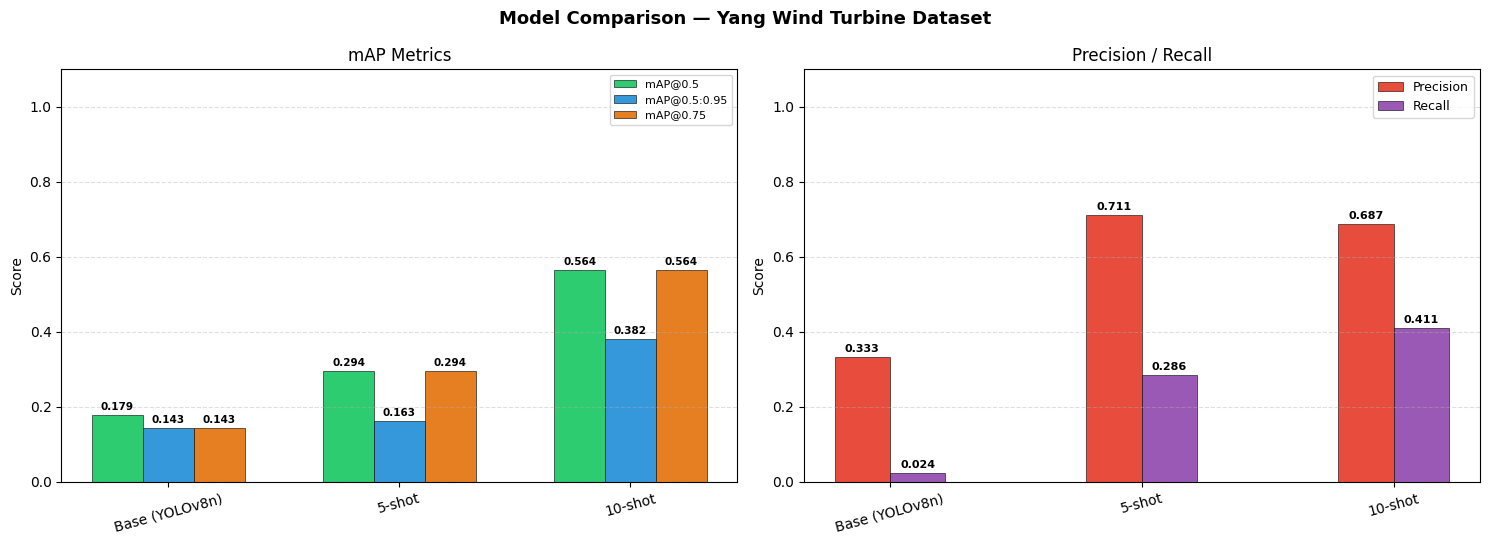

✓ Comparison chart saved → /kaggle/working/fewshot_yang/model_comparison.png


In [18]:
# ── Grouped bar chart comparison ─────────────────────────────────────────────
if not comparison_df.empty:
    df = comparison_df
    x  = np.arange(len(df))
    w  = 0.22
    palette = ["#2ecc71", "#3498db", "#e67e22", "#e74c3c", "#9b59b6"]

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
    fig.suptitle("Model Comparison — Yang Wind Turbine Dataset",
                 fontsize=13, fontweight="bold")

    # ── mAP chart ────────────────────────────────────────────────────────────
    ax1 = axes[0]
    for idx, (col, color) in enumerate(zip(["mAP@0.5", "mAP@0.5:0.95", "mAP@0.75"], palette)):
        offset = (idx - 1) * w
        bars = ax1.bar(x + offset, df[col], w, label=col, color=color,
                       edgecolor="black", linewidth=0.4)
        for bar in bars:
            h = bar.get_height()
            if h > 0:
                ax1.text(bar.get_x() + bar.get_width()/2, h + 0.008,
                         f"{h:.3f}", ha="center", va="bottom", fontsize=7.5, fontweight="bold")
    ax1.set_ylabel("Score")
    ax1.set_title("mAP Metrics")
    ax1.set_xticks(x)
    ax1.set_xticklabels(df.index, rotation=15)
    ax1.set_ylim(0, 1.10)
    ax1.legend(fontsize=8)
    ax1.grid(axis="y", linestyle="--", alpha=0.4)

    # ── Precision / Recall chart ──────────────────────────────────────────────
    ax2 = axes[1]
    for idx, (col, color) in enumerate(zip(["Precision", "Recall"], palette[3:])):
        offset = (idx - 0.5) * w
        bars = ax2.bar(x + offset, df[col], w, label=col, color=color,
                       edgecolor="black", linewidth=0.4)
        for bar in bars:
            h = bar.get_height()
            if h > 0:
                ax2.text(bar.get_x() + bar.get_width()/2, h + 0.008,
                         f"{h:.3f}", ha="center", va="bottom", fontsize=8, fontweight="bold")
    ax2.set_ylabel("Score")
    ax2.set_title("Precision / Recall")
    ax2.set_xticks(x)
    ax2.set_xticklabels(df.index, rotation=15)
    ax2.set_ylim(0, 1.10)
    ax2.legend(fontsize=9)
    ax2.grid(axis="y", linestyle="--", alpha=0.4)

    plt.tight_layout()
    save_fig = OUTPUT_DIR / "model_comparison.png"
    plt.savefig(save_fig, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✓ Comparison chart saved → {save_fig}")
else:
    print("No models evaluated yet — train first then re-run this cell.")


## 12. Export Best Model

In [19]:
# Choose best model based on mAP@0.5 from comparison table
best_pt_path = None
if not comparison_df.empty and "mAP@0.5" in comparison_df.columns:
    valid_map = {k: v for k, v in zip(comparison_df.index, comparison_df["mAP@0.5"])
                 if k != "Base (YOLOv8n)"}
    if valid_map:
        best_model_name = max(valid_map, key=valid_map.get)
        shot_num = int(best_model_name.split("-")[0]) if "shot" in best_model_name else None
        if shot_num:
            best_pt_path = OUTPUT_DIR / "runs" / f"{shot_num}shot" / "weights" / "best.pt"

if best_pt_path is None:
    # Fallback: use 5-shot
    best_pt_path = best_5shot

if best_pt_path.exists():
    print(f"Loading best model: {best_pt_path}")
    best_model = YOLO(str(best_pt_path))

    total_params = sum(p.numel() for p in best_model.model.parameters())
    print(f"\n✓ Model parameters : {total_params:,} ({total_params/1e6:.2f}M)")

    # Export to ONNX
    print("\nExporting to ONNX …")
    onnx_path = best_model.export(
        format="onnx", imgsz=640, simplify=True, dynamic=False, opset=12
    )
    print(f"✓ ONNX   → {onnx_path}")

    # Save .pt copy
    final_pt = BASE_DIR / "best_fewshot_wind_turbine.pt"
    shutil.copy2(best_pt_path, final_pt)
    print(f"✓ .pt    → {final_pt}")
else:
    print("⚠  best.pt not found — please run the training cells first.")


Loading best model: /kaggle/working/fewshot_yang/runs/10shot/weights/best.pt

✓ Model parameters : 3,011,433 (3.01M)

Exporting to ONNX …
Ultralytics 8.4.15 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/kaggle/working/fewshot_yang/runs/10shot/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 7, 8400) (6.0 MB)
requirements: Ultralytics requirements ['onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 261ms
Prepared 2 packages in 2.61s
Installed 2 packages in 9ms
 + onnxruntime-gpu==1.24.2
 + onnxslim==0.1.85

requirements: AutoUpdate success ✅ 3.4s
WARNING ⚠️ requirements: Restart runtime or rerun command f

## 13. Inference Demo on Validation Images

✓ Inference demo saved → /kaggle/working/fewshot_yang/inference_demo.png


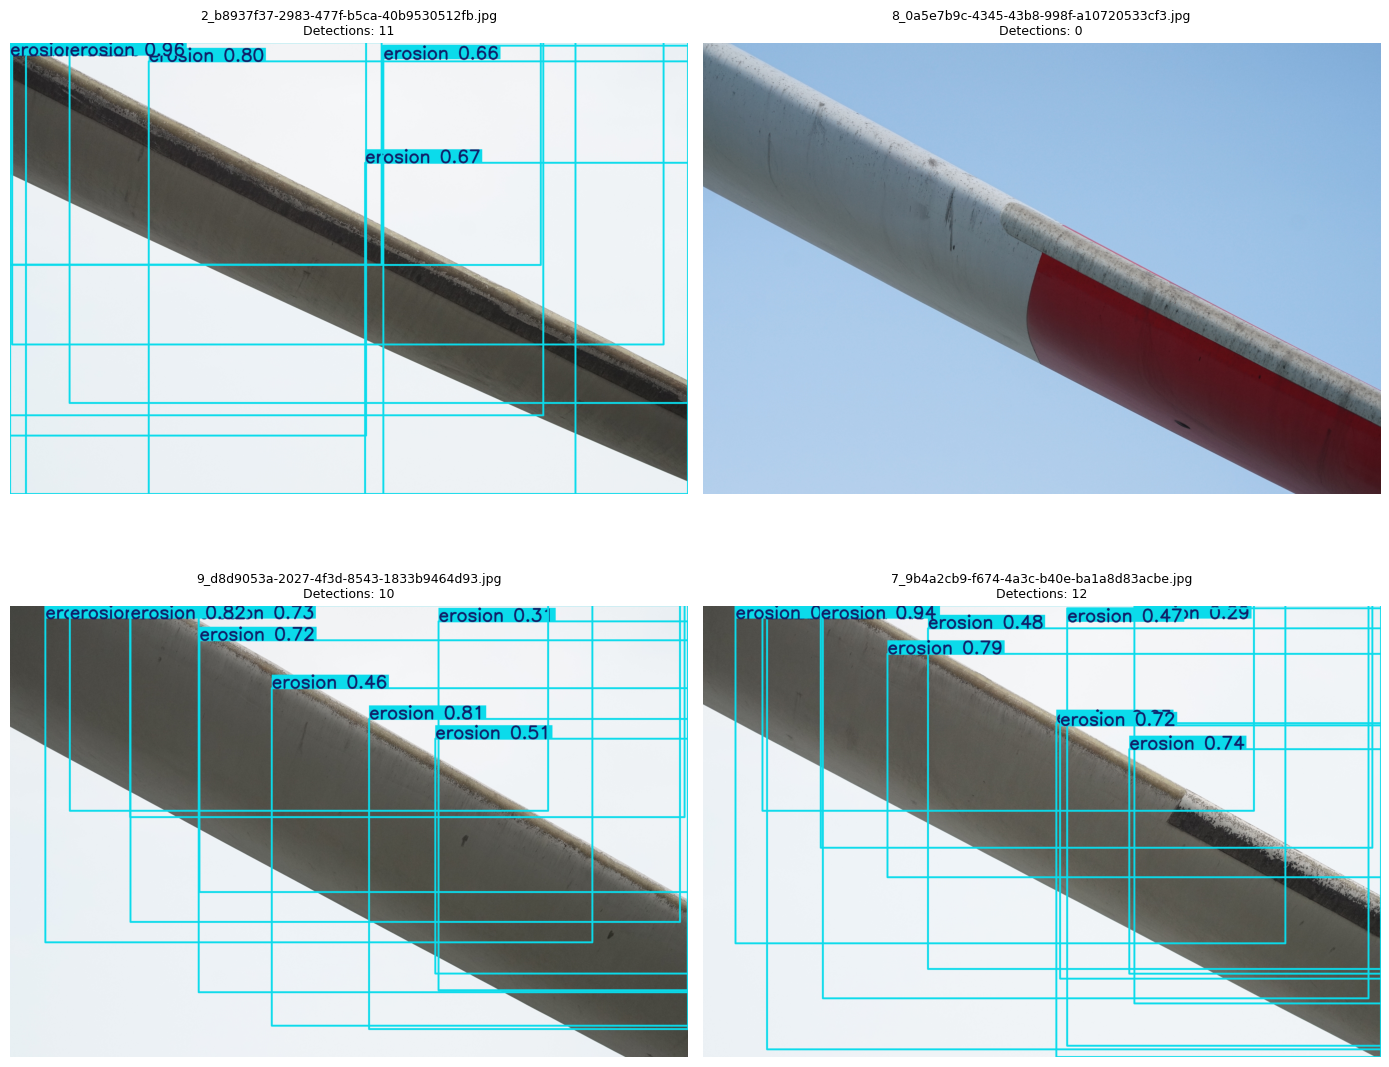

In [20]:
def run_inference_demo(model_path: Path, images_dir: Path,
                       n_samples: int = 4, save_path: Path | None = None):
    """
    Sample `n_samples` validation images, run prediction, and display a grid
    with annotated bounding boxes and detection counts.
    """
    model = YOLO(str(model_path))
    images_dir = Path(images_dir)

    img_files = (list(images_dir.glob("*.jpg")) +
                 list(images_dir.glob("*.jpeg")) +
                 list(images_dir.glob("*.png")))
    if not img_files:
        print("No images found in:", images_dir)
        return

    sampled = random.sample(img_files, min(n_samples, len(img_files)))
    n_cols  = 2
    n_rows  = (len(sampled) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 6 * n_rows))
    axes = np.array(axes).flatten()

    for idx, img_path in enumerate(sampled):
        results  = model.predict(str(img_path), conf=0.25, verbose=False)
        annotated = results[0].plot()
        annotated = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

        n_det = len(results[0].boxes) if results[0].boxes is not None else 0
        axes[idx].imshow(annotated)
        axes[idx].set_title(f"{img_path.name}\nDetections: {n_det}", fontsize=9)
        axes[idx].axis("off")

    # Hide unused axes
    for idx in range(len(sampled), len(axes)):
        axes[idx].axis("off")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"✓ Inference demo saved → {save_path}")
    plt.show()


# ── Run demo ──────────────────────────────────────────────────────────────────
demo_model = best_5shot if best_5shot.exists() else best_10shot
if demo_model.exists():
    run_inference_demo(
        model_path = demo_model,
        images_dir = YOLO_DATASET / "val" / "images",
        n_samples  = 4,
        save_path  = OUTPUT_DIR / "inference_demo.png",
    )
else:
    print("⚠  No trained model found — run training first.")


## Summary

### Pipeline
1. **Data Parsing** — LabelMe JSON polygons → YOLO bbox `.txt` files (80/20 split)
2. **3 Damage Classes** — `contamination`, `erosion`, `structural`
3. **Balanced Few-Shot Splits** — 3, 5, 10, 15-shot datasets preserving class coverage
4. **Lightweight YOLOv8n** — ~3M param backbone, small batch (4), heavy augmentation
5. **Training Optimisations** — AdamW, LR=0.001, cosine decay, early-stop (patience=30)
6. **Evaluation Metrics** — mAP@0.5, mAP@0.5:0.95, mAP@0.75, Precision, Recall
7. **Visualisations** — Class-wise PR curves (one subplot per class), confusion matrix (raw + normalised)
8. **Export** — best.pt copied + ONNX export for deployment

### Key Hyperparameters
| Parameter | Value | Reason |
|-----------|-------|--------|
| `batch` | 4 | Few-shot data is small; avoids running out of images per batch |
| `mosaic` | 0.8 | Creates synthetic multi-blade composites |
| `mixup` | 0.2 | Interpolates between images for regularisation |
| `copy_paste` | 0.2 | Copies damage instances across images |
| `lr0` | 0.001 | Lower LR preserves pretrained features |
| `patience` | 30 | Prevents severe overfitting on tiny sets |

### Next Steps
- Try meta-learning (MAML / ProtoNet) for better few-shot generalisation
- Semi-supervised learning: pseudo-label the 1053 unannotated blade images
- Active learning: select the most informative images to label next